<div dir="rtl" style="text-align: right;">

# פרויקט למידת מכונה - חלק ב'

בחלק זה בוצעו הכנת נתונים, אימון מודלים והשוואת ביצועים לצורך חיזוי שביעות הרצון של נוסעי חברת התעופה.

לאחר טעינת הנתונים ובדיקת תקינותם, יושמו שלבי הניקוי והעיבוד המקדים בהתאם להחלטות חלק א׳. בהמשך חולק קובץ האימון לסט אימון וסט אימות בחלוקה שכבתית, ונבחנו שני מודלים עיקריים: עץ החלטה ורשת נוירונים מסוג MLP.

 עבור כל מודל בוצע כיוונון היפר־פרמטרים, ולאחר מכן נותחו ביצועיו באמצעות מדדי סיווג, מטריצות בלבול וכלים פרשניים רלוונטיים.

בסיום התהליך בוצעה השוואה בין המודלים על בסיס ביצועיהם בסט האימות, ונבחר המודל המתאים ביותר להגשה לתחרות. המודל הנבחר שימש לחיזוי רמת שביעות הרצון עבור קובץ המבחן הסופי.

</div>


<div dir="rtl" style="text-align: right;">

## 1. ייבוא ספריות והגדרות ראשוניות

נייבא ספריות בסיסיות הדרושות לטעינת הנתונים, בדיקה ראשונית וחלוקה לסט אימון וסט אימות. בהמשך נוסיף ספריות נוספות רק כאשר נגיע לסעיפי המודלים.

</div>


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd


RANDOM_STATE = 42

<div dir="rtl" style="text-align: right;">

## 2. טעינת קבצי הנתונים

נטען את קובץ האימון, קובץ המבחן הסופי וקובץ הדוגמה להגשה. בשלב זה קובץ המבחן הסופי משמש רק לבדיקת מבנה, ולא לבחירת מודלים או לכוונון שלהם.

</div>


In [2]:
from pathlib import Path
import pandas as pd

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

BASE_DIR = Path.cwd()

TRAIN_FILE = BASE_DIR / "Xy_train.csv"
TEST_FILE = BASE_DIR / "X_test.csv"
EXAMPLE_SUBMISSION_FILE = BASE_DIR / "y test example.xlsx"

required_files = [TRAIN_FILE, TEST_FILE, EXAMPLE_SUBMISSION_FILE]

missing_files = [
    file_path.name
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    print("The following files are missing:")
    print(missing_files)

    if IN_COLAB:
        print("Please select and upload the missing files now:")
        uploaded = files.upload()
    else:
        raise FileNotFoundError(f"The following files are missing from the working directory: {missing_files}")

# בדיקה חוזרת אחרי ההעלאה
missing_files = [
    file_path.name
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(f"The following files are still missing: {missing_files}")

train_raw = pd.read_csv(TRAIN_FILE)
test_raw = pd.read_csv(TEST_FILE)
example_submission = pd.read_excel(EXAMPLE_SUBMISSION_FILE)

display(train_raw.head())
display(test_raw.head())
display(example_submission.head())

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Plane colors,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Female,Loyal Customer,35.0,Personal Travel,Eco,731.0,2,4.0,3.0,1.0,...,3.0,4.0,NaN,5.0,1.0,5.0,2.0,18.0,1.0,neutral or dissatisfied
1,Female,Loyal Customer,35.0,Business travel,Unknown,354.0,2,3.0,3.0,3.0,...,3.0,2.0,3.0,3.0,1.0,3.0,3.0,0.0,0.0,neutral or dissatisfied
2,Male,disloyal Customer,43.0,Business travel,Eco,719.0,3,2.0,2.0,2.0,...,2.0,1.0,3.0,1.0,2.0,4.0,4.0,0.0,0.0,neutral or dissatisfied
3,Male,disloyal Customer,21.0,Business travel,Eco,772.0,1,2.0,2.0,2.0,...,2.0,3.0,3.0,3.0,3.0,5.0,2.0,11.0,7.0,neutral or dissatisfied
4,Male,Loyal Customer,39.0,Personal Travel,Eco,618.0,1,4.0,2.0,4.0,...,2.0,4.0,NaN,3.0,3.0,5.0,2.0,0.0,0.0,neutral or dissatisfied


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Plane colors,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Food and drink,Seat comfort,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,Female,Loyal Customer,69,Personal Travel,Eco,363,2,2,5,2,...,1,5,3,5.0,3,3,3,4,0,0.0
1,Female,disloyal Customer,11,Business travel,Eco,231,2,2,0,2,...,1,1,4,2.0,4,3,5,1,0,0.0
2,Female,Loyal Customer,38,Business travel,Business,3394,2,5,5,0,...,2,5,5,NaN,5,4,5,3,13,28.0
3,Female,Loyal Customer,55,Business travel,Business,2340,1,5,5,5,...,2,5,4,4.0,4,4,4,4,108,107.0
4,Female,disloyal Customer,72,Business travel,Eco,129,1,4,5,4,...,4,2,1,3.0,5,5,2,2,14,22.0


,target
0,1
1,0
2,0
3,0
4,1


<div dir="rtl" style="text-align: right;">

## 3. בדיקות מבנה בסיסיות

נבדוק את גודל הקבצים, שמות העמודות, ערכים חסרים וכפילויות. בדיקות אלה נועדו לוודא שאנחנו עובדים עם הקבצים הנכונים לפני שמתחילים לבנות מודלים.

</div>


In [3]:
data_summary = pd.DataFrame(
    {
        "File": ["Train", "Final Test", "Sample Submission"],
        "Number of Rows": [len(train_raw), len(test_raw), len(example_submission)],
        "Number of Columns": [train_raw.shape[1], test_raw.shape[1], example_submission.shape[1]],
        "Number of Missing Values": [
            int(train_raw.isna().sum().sum()),
            int(test_raw.isna().sum().sum()),
            int(example_submission.isna().sum().sum()),
        ],
        "Number of Duplicate Rows": [
            int(train_raw.duplicated().sum()),
            int(test_raw.duplicated().sum()),
            int(example_submission.duplicated().sum()),
        ],
    }
)

display(data_summary)

,File,Number of Rows,Number of Columns,Number of Missing Values,Number of Duplicate Rows
0,Train,9000,22,3196,0
1,Final Test,1000,21,354,0
2,Sample Submission,185,1,0,183


In [4]:
columns_summary = pd.DataFrame(
    {
        "Train Columns": pd.Series(train_raw.columns),
        "Final Test Columns": pd.Series(test_raw.columns),
        "Sample Submission Columns": pd.Series(example_submission.columns),
    }
)

display(columns_summary)

,Train Columns,Final Test Columns,Sample Submission Columns
0,Gender,Gender,target
1,Customer Type,Customer Type,NaN
2,Age,Age,NaN
3,Type of Travel,Type of Travel,NaN
4,Class,Class,NaN
5,Flight Distance,Flight Distance,NaN
6,Plane colors,Plane colors,NaN
7,Inflight wifi service,Inflight wifi service,NaN
8,Departure/Arrival time convenient,Departure/Arrival time convenient,NaN
9,Ease of Online booking,Ease of Online booking,NaN


In [5]:
missing_summary = pd.DataFrame(
    {
        "Missing in Train": train_raw.isna().sum(),
        "Missing in Final Test": test_raw.isna().sum(),
    }
).fillna(0).astype(int)

display(missing_summary)

,Missing in Train,Missing in Final Test
Age,1,0
Arrival Delay in Minutes,471,54
Baggage handling,1,0
Checkin service,1,0
Class,1,0
Cleanliness,1,0
Customer Type,1,0
Departure Delay in Minutes,1,0
Departure/Arrival time convenient,2,0
Ease of Online booking,2,0


<div dir="rtl" style="text-align: right;">

## 4. זיהוי עמודת המטרה והפרדת מאפיינים

נזהה את עמודת המטרה מתוך קובץ האימון בפועל. לא נניח מראש את שם העמודה או את צורת הכתיבה שלה. לאחר הזיהוי נפריד בין מאפייני הקלט לבין משתנה המטרה.

</div>


In [6]:
train_columns = list(train_raw.columns)
test_columns = list(test_raw.columns)

columns_only_in_train = [column for column in train_columns if column not in test_columns]

if len(columns_only_in_train) != 1:
    raise ValueError(
        "The target column could not be identified unambiguously. "
        f"Columns found only in the training file: {columns_only_in_train}"
    )

target_column = columns_only_in_train[0]
feature_columns = [column for column in train_columns if column != target_column]

missing_in_test = [column for column in feature_columns if column not in test_columns]
extra_in_test = [column for column in test_columns if column not in feature_columns]

if missing_in_test or extra_in_test:
    raise ValueError(
        "The feature-column structures of the training and final test files do not match. "
        f"Missing from final test: {missing_in_test}; extra in final test: {extra_in_test}"
    )

X = train_raw[feature_columns].copy()
y = train_raw[target_column].copy()
X_test_final = test_raw[feature_columns].copy()

print(f"Detected target column: {target_column}")
print(f"Number of features: {len(feature_columns)}")

Detected target column: satisfaction
Number of features: 21


In [7]:
target_distribution = (
    y.value_counts(dropna=False)
    .rename_axis("Target Value")
    .reset_index(name="Number of Records")
)
target_distribution["Percentage"] = (target_distribution["Number of Records"] / len(y) * 100).round(2)

display(target_distribution)

,Target Value,Number of Records,Percentage
0,neutral or dissatisfied,5071,56.34
1,satisfied,3928,43.64
2,NaN,1,0.01


<div dir="rtl" style="text-align: right;">

## 5. ניקוי נתונים לפי החלטות חלק א'

לפני החלוקה מוסרות רק רשומות שאינן כשירות ללמידה מפוקחת: רשומה ללא ערך במשתנה המטרה ורשומה בעלת ערך `Class` לא חוקי. בשלב זה לא מחושב חציון, שכיח או כל נתון סטטיסטי אחר.

הניקוי הלומד מהנתונים ממומש באמצעות `AirlinePartACleaner` בתוך כל Pipeline. המתודה `fit` לומדת ערכי השלמה מנתוני האימון בלבד, והמתודה `transform` מחילה אותם על אימות או מבחן ללא התאמה מחדש וללא מחיקת רשומות. כך אותו תהליך פועל גם בנפרד בכל fold של Cross-Validation.

</div>


In [8]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted


VALID_CLASSES = ["Eco", "Eco Plus", "Business", "Unknown"]

service_columns = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Seat comfort",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness",
]

numeric_like_columns = [
    "Age",
    "Flight Distance",
    "Plane colors",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes",
    *service_columns,
]

engineered_features = ["Age_Category", "Flight_Type", "Total_Service_Score"]


def _safe_numeric_median(series, fallback=0.0):
    value = pd.to_numeric(series, errors="coerce").median()
    return float(fallback if pd.isna(value) else value)


def _safe_mode(series, fallback="Unknown"):
    modes = series.dropna().mode()
    return fallback if modes.empty else modes.iloc[0]


class AirlinePartACleaner(BaseEstimator, TransformerMixin):
    """Learn Part A cleaning values in fit and apply them unchanged in transform."""

    def _normalize_base_values(self, X):
        data = X.copy()

        for column in numeric_like_columns:
            if column in data.columns:
                data[column] = pd.to_numeric(data[column], errors="coerce")

        if "Class" in data.columns:
            invalid_class = data["Class"].notna() & ~data["Class"].isin(VALID_CLASSES)
            data.loc[invalid_class, "Class"] = np.nan
            data["Class"] = data["Class"].replace("Unknown", np.nan).fillna("Business")

        if "Gate location" in data.columns:
            invalid_gate = data["Gate location"].notna() & ~data["Gate location"].between(1, 5)
            data.loc[invalid_gate, "Gate location"] = np.nan

        if "Age" in data.columns:
            invalid_age = data["Age"].notna() & ~data["Age"].between(0, 110)
            data.loc[invalid_age, "Age"] = np.nan

        if "Flight Distance" in data.columns:
            negative_distance = data["Flight Distance"].notna() & (data["Flight Distance"] < 0)
            data.loc[negative_distance, "Flight Distance"] = np.nan

        return data

    @staticmethod
    def _group_lookup(data, columns, mapping):
        keys = pd.MultiIndex.from_frame(data[columns])
        return pd.Series(keys.map(mapping), index=data.index, dtype="float64")

    def _apply_specialized_imputation(self, data):
        result = data.copy()

        if "Gate location" in result.columns:
            result["Gate location"] = result["Gate location"].fillna(self.gate_median_)

        if {"Leg room service", "Class", "Type of Travel"}.issubset(result.columns):
            group_values = self._group_lookup(
                result,
                ["Class", "Type of Travel"],
                self.leg_group_medians_,
            )
            class_values = result["Class"].map(self.leg_class_medians_)
            result["Leg room service"] = (
                result["Leg room service"]
                .fillna(group_values)
                .fillna(class_values)
                .fillna(self.leg_global_median_)
            )

        if "Age" in result.columns:
            result["Age"] = result["Age"].fillna(self.age_median_)

        if {"Flight Distance", "Class", "Type of Travel"}.issubset(result.columns):
            group_values = self._group_lookup(
                result,
                ["Class", "Type of Travel"],
                self.distance_group_medians_,
            )
            class_values = result["Class"].map(self.distance_class_medians_)
            result["Flight Distance"] = (
                result["Flight Distance"]
                .fillna(group_values)
                .fillna(class_values)
                .fillna(self.distance_global_median_)
            )

        return result

    def fit(self, X, y=None):
        data = self._normalize_base_values(X)
        self.feature_names_in_ = np.asarray(data.columns, dtype=object)
        self.n_features_in_ = len(self.feature_names_in_)

        self.gate_median_ = _safe_numeric_median(data["Gate location"])

        leg_series = data["Leg room service"]
        self.leg_group_medians_ = (
            data.groupby(["Class", "Type of Travel"], observed=True)["Leg room service"]
            .median()
            .dropna()
            .to_dict()
        )
        self.leg_class_medians_ = (
            data.groupby("Class", observed=True)["Leg room service"]
            .median()
            .dropna()
            .to_dict()
        )
        self.leg_global_median_ = _safe_numeric_median(leg_series)

        self.age_median_ = _safe_numeric_median(data["Age"])

        distance_series = data["Flight Distance"]
        self.distance_group_medians_ = (
            data.groupby(["Class", "Type of Travel"], observed=True)["Flight Distance"]
            .median()
            .dropna()
            .to_dict()
        )
        self.distance_class_medians_ = (
            data.groupby("Class", observed=True)["Flight Distance"]
            .median()
            .dropna()
            .to_dict()
        )
        self.distance_global_median_ = _safe_numeric_median(distance_series)

        working = self._apply_specialized_imputation(data)
        if "Plane colors" in working.columns:
            working = working.drop(columns=["Plane colors"])

        self.numeric_medians_ = {
            column: _safe_numeric_median(working[column])
            for column in working.select_dtypes(include=[np.number]).columns
        }
        self.categorical_modes_ = {
            column: _safe_mode(working[column])
            for column in working.columns
            if column not in self.numeric_medians_
        }

        self.output_features_ = [
            column for column in working.columns if column not in engineered_features
        ] + engineered_features

        self.fit_statistics_ = {
            "Fit Rows": len(data),
            "Gate Location Median": self.gate_median_,
            "Age Median": self.age_median_,
            "Global Leg Room Median": self.leg_global_median_,
            "Global Flight Distance Median": self.distance_global_median_,
        }
        return self

    def transform(self, X):
        check_is_fitted(self, "output_features_")
        data = self._normalize_base_values(X)
        data = self._apply_specialized_imputation(data)

        if "Plane colors" in data.columns:
            data = data.drop(columns=["Plane colors"])

        for column, median in self.numeric_medians_.items():
            if column in data.columns:
                data[column] = data[column].fillna(median)

        for column, mode in self.categorical_modes_.items():
            if column in data.columns:
                data[column] = data[column].fillna(mode)

        data["Age_Category"] = pd.cut(
            data["Age"],
            bins=[0, 12, 18, 65, np.inf],
            labels=["Child", "Teen", "Adult", "Senior"],
            include_lowest=True,
        )
        data["Flight_Type"] = pd.cut(
            data["Flight Distance"],
            bins=[0, 1000, 3000, np.inf],
            labels=["Short-Haul", "Medium-Haul", "Long-Haul"],
            include_lowest=True,
        )
        data["Total_Service_Score"] = data[service_columns].mean(axis=1)

        data = data.reindex(columns=self.output_features_)
        if data.isna().any().any():
            missing = data.columns[data.isna().any()].tolist()
            raise ValueError(f"Missing values remain after AirlinePartACleaner.transform: {missing}")

        return data

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, "output_features_")
        return np.asarray(self.output_features_, dtype=object)


# Only deterministic eligibility filtering is allowed before the split.
missing_target_mask = y.isna()
invalid_class_mask = X["Class"].notna() & ~X["Class"].isin(VALID_CLASSES)
eligible_mask = ~missing_target_mask & ~invalid_class_mask

X_model = X.loc[eligible_mask].copy()
y_model = y.loc[eligible_mask].copy()
X_test_final = test_raw[feature_columns].copy()

eligibility_summary = pd.DataFrame(
    {
        "Check": [
            "Original labeled rows",
            "Rows removed: missing target",
            "Rows removed: invalid Class",
            "Eligible labeled rows",
            "Final test rows retained",
        ],
        "Result": [
            len(X),
            int(missing_target_mask.sum()),
            int(invalid_class_mask.sum()),
            len(X_model),
            len(X_test_final),
        ],
    }
)
display(eligibility_summary)

print("No medians, modes, or grouped statistics were learned before the split.")


,Check,Result
0,Original labeled rows,9000
1,Rows removed: missing target,1
2,Rows removed: invalid Class,1
3,Eligible labeled rows,8998
4,Final test rows retained,1000


No medians, modes, or grouped statistics were learned before the split.


<div dir="rtl" style="text-align: right;">

### בדיקות סינון לפני החלוקה

נבדוק שרק שתי הרשומות שאינן כשירות ללמידה הוסרו, ושקובץ המבחן הסופי עדיין מכיל את כל הרשומות בסדר המקורי. בדיקות הניקוי הסטטיסטי יבוצעו רק לאחר החלוקה, באמצעות Cleaner שמותאם לסט האימון.

</div>


In [9]:
rows_check = pd.DataFrame(
    {
        "File": ["Eligible Labeled Data", "Final Test"],
        "Rows Before Eligibility Filter": [len(train_raw), len(test_raw)],
        "Rows After Eligibility Filter": [len(X_model), len(X_test_final)],
        "Rows Removed": [int((~eligible_mask).sum()), 0],
    }
)
display(rows_check)

original_test_index = X_test_final.index.copy()
original_test_length = len(X_test_final)

assert len(X_model) == 8998
assert y_model.isna().sum() == 0
assert len(X_test_final) == len(test_raw) == 1000
assert X_test_final.index.equals(test_raw.index)

print("Eligibility filtering and raw final-test preservation checks passed.")


,File,Rows Before Eligibility Filter,Rows After Eligibility Filter,Rows Removed
0,Eligible Labeled Data,9000,8998,2
1,Final Test,1000,1000,0


Eligibility filtering and raw final-test preservation checks passed.


<div dir="rtl" style="text-align: right;">

## 6. הכנת נתונים ראשונית לאימון ולאימות

הנתונים נשמרים בשלב זה במבנה הגולמי שלהם. הסרת `Plane colors`, השלמת החוסרים ויצירת `Age_Category`, `Flight_Type` ו־`Total_Service_Score` מתבצעות בתוך `AirlinePartACleaner` לאחר החלוקה. לאחר הטרנספורמציה מתקבלים 23 מאפייני קלט.

</div>


In [10]:
if y_model.isna().any():
    raise ValueError("Missing target values remain after eligibility filtering.")

print("The raw eligible data is ready for the training-validation split.")


The raw eligible data is ready for the training-validation split.


<div dir="rtl" style="text-align: right;">

## 7. חלוקה לסט אימון וסט אימות

החלוקה בוצעה ביחס 80:20 ובדגימה שכבתית עם `random_state=42`. מתוך 8,998 הרשומות הכשירות התקבלו 7,198 רשומות אימון ו־1,800 רשומות אימות. בסט האימון 56.36% מהתצפיות הן `neutral or dissatisfied` ו־43.64% הן `satisfied`; בסט האימות היחסים הם 56.33% ו־43.67% בהתאמה.

סט האימות נשמר מחוץ לכל תהליכי הניקוי, הכיוונון וה־Cross-Validation, ומשמש רק להערכת המודלים לאחר בחירת ההיפר־פרמטרים.

</div>


In [11]:
from sklearn.model_selection import train_test_split

stratify_target = y_model if y_model.nunique(dropna=False) > 1 else None

X_train, X_valid, y_train, y_valid = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_target,
)

split_summary = pd.DataFrame(
    {
        "Set": ["Train", "Validation", "Final Test"],
        "Number of Records": [len(X_train), len(X_valid), len(X_test_final)],
        "Raw Number of Features": [X_train.shape[1], X_valid.shape[1], X_test_final.shape[1]],
    }
)
display(split_summary)


,Set,Number of Records,Raw Number of Features
0,Train,7198,21
1,Validation,1800,21
2,Final Test,1000,21


In [12]:
train_target_distribution = y_train.value_counts(normalize=True, dropna=False).rename("Train")
valid_target_distribution = y_valid.value_counts(normalize=True, dropna=False).rename("Validation")

split_target_distribution = (
    pd.concat([train_target_distribution, valid_target_distribution], axis=1)
    .fillna(0)
    .mul(100)
    .round(2)
)

display(split_target_distribution)

,Train,Validation
satisfaction,,
neutral or dissatisfied,56.36,56.33
satisfied,43.64,43.67


<div dir="rtl" style="text-align: right;">

### בדיקת הניקוי לאחר החלוקה

לצורך בדיקת תקינות בלבד נתאים Cleaner ל־`X_train`, ולאחר מכן נפעיל `transform` על האימון, האימות והמבחן. אין קריאת `fit` על `X_valid` או על `X_test`.

</div>


In [13]:
cleaner_audit = AirlinePartACleaner().fit(X_train)
X_train_clean_audit = cleaner_audit.transform(X_train)
X_valid_clean_audit = cleaner_audit.transform(X_valid)
X_test_clean_audit = cleaner_audit.transform(X_test_final)

cleaning_audit = pd.DataFrame(
    {
        "Set": ["Train", "Validation", "Final Test"],
        "Rows": [len(X_train_clean_audit), len(X_valid_clean_audit), len(X_test_clean_audit)],
        "Features After Cleaning": [
            X_train_clean_audit.shape[1],
            X_valid_clean_audit.shape[1],
            X_test_clean_audit.shape[1],
        ],
        "Missing Values After Transform": [
            int(X_train_clean_audit.isna().sum().sum()),
            int(X_valid_clean_audit.isna().sum().sum()),
            int(X_test_clean_audit.isna().sum().sum()),
        ],
    }
)
display(pd.DataFrame([cleaner_audit.fit_statistics_], index=["Learned from X_train only"]))
display(cleaning_audit)

assert cleaner_audit.fit_statistics_["Fit Rows"] == len(X_train)
assert X_train_clean_audit.shape[1] == X_valid_clean_audit.shape[1] == X_test_clean_audit.shape[1] == 23
assert X_train_clean_audit.isna().sum().sum() == 0
assert X_valid_clean_audit.isna().sum().sum() == 0
assert X_test_clean_audit.isna().sum().sum() == 0
assert len(X_test_final) == original_test_length
assert X_test_final.index.equals(original_test_index)
assert X_test_clean_audit.index.equals(original_test_index)

print("Cleaner audit passed: fit used X_train only; validation and test were transform-only.")


,Fit Rows,Gate Location Median,Age Median,Global Leg Room Median,Global Flight Distance Median
Learned from X_train only,7198,3.0,41.0,3.0,853.0


,Set,Rows,Features After Cleaning,Missing Values After Transform
0,Train,7198,23,0
1,Validation,1800,23,0
2,Final Test,1000,23,0


Cleaner audit passed: fit used X_train only; validation and test were transform-only.


<div dir="rtl" style="text-align: right;">

## 8. עצי החלטה

בסעיף זה נבנה עץ החלטה מלא, נכוונן היפר-פרמטרים, נציג את העץ הנבחר, ננתח חשיבות משתנים ונעביר רשומת אימות לדוגמה דרך העץ.

</div>

<div dir="rtl" style="text-align: right;">

### 8.1 הכנת הנתונים לעץ החלטה (Data Preparation)

משתנה המטרה `satisfaction` מומר לערכים בינאריים: `neutral or dissatisfied` ל־0 ו־`satisfied` ל־1. ה־Pipeline מתחיל ב־`AirlinePartACleaner`, ולכן ערכי ההשלמה נלמדים מחדש רק מנתוני האימון של כל fold.

לאחר הניקוי, selectors דינמיים מזהים 17 משתנים מספריים ו־6 משתנים קטגוריאליים. המשתנים המספריים עוברים ללא סטנדרטיזציה, והקטגוריאליים מקודדים באמצעות `OneHotEncoder(handle_unknown='ignore')`.

</div>


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate

TARGET_MAP = {
    "neutral or dissatisfied": 0,
    "satisfied": 1,
}

y_train_dt = y_train.map(TARGET_MAP).astype(int)
y_valid_dt = y_valid.map(TARGET_MAP).astype(int)

DT_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
DT_SCORING = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

print("Target variable mapped successfully. Decision Tree CV: 5 stratified shuffled folds.")


Target variable mapped successfully. Decision Tree CV: 5 stratified shuffled folds.


In [15]:
numeric_selector = make_column_selector(dtype_include=np.number)
categorical_selector = make_column_selector(dtype_exclude=np.number)


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_dt_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("numeric", "passthrough", numeric_selector),
            ("categorical", make_one_hot_encoder(), categorical_selector),
        ],
        remainder="drop",
    )


def build_dt_pipeline(model):
    return Pipeline(
        steps=[
            ("cleaner", AirlinePartACleaner()),
            ("preprocess", make_dt_preprocessor()),
            ("model", model),
        ]
    )


numeric_features_dt = X_train_clean_audit.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_dt = [
    column for column in X_train_clean_audit.columns if column not in numeric_features_dt
]

dt_preprocessing_summary = pd.DataFrame(
    {
        "Variable Type": ["Numeric", "Categorical"],
        "Number of Variables": [len(numeric_features_dt), len(categorical_features_dt)],
        "Preprocessing Operation": ["Passthrough (no change)", "One-Hot Encoding"],
    }
)
display(dt_preprocessing_summary)


,Variable Type,Number of Variables,Preprocessing Operation
0,Numeric,17,Passthrough (no change)
1,Categorical,6,One-Hot Encoding


<div dir="rtl" style="text-align: right;">

### 8.2 בניית עץ החלטה מלא (Full Decision Tree)

עץ מלא משמש כנקודת בסיס לבדיקת התאמת יתר. הוא נבחן על נתוני האימון וב־5-fold Cross-Validation בתוך סט האימון בלבד; סט האימות אינו נחשף בשלב זה.

</div>


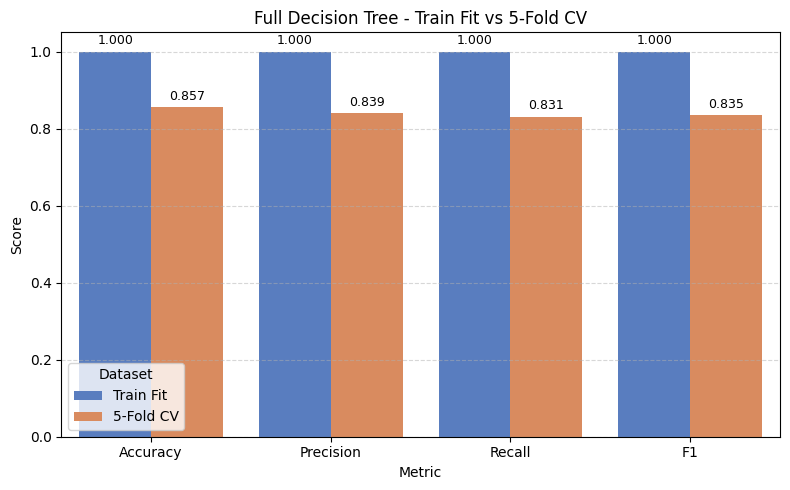

,Dataset,Accuracy,Precision,Recall,F1
0,Train Fit,1.0000,1.0000,1.0000,1.0000
1,5-Fold CV,0.8569,0.8393,0.8313,0.8352


Mean full-tree CV generalization gap: 0.1431


In [16]:
full_dt_pipeline = build_dt_pipeline(
    DecisionTreeClassifier(random_state=RANDOM_STATE)
)

full_dt_cv = cross_validate(
    full_dt_pipeline,
    X_train,
    y_train_dt,
    cv=DT_CV,
    scoring=DT_SCORING,
    return_train_score=True,
    n_jobs=-1,
)

full_dt_pipeline.fit(X_train, y_train_dt)
full_dt_train_predictions = full_dt_pipeline.predict(X_train)

full_dt_metrics = pd.DataFrame(
    [
        {
            "Dataset": "Train Fit",
            "Accuracy": accuracy_score(y_train_dt, full_dt_train_predictions),
            "Precision": precision_score(y_train_dt, full_dt_train_predictions, zero_division=0),
            "Recall": recall_score(y_train_dt, full_dt_train_predictions, zero_division=0),
            "F1": f1_score(y_train_dt, full_dt_train_predictions, zero_division=0),
        },
        {
            "Dataset": "5-Fold CV",
            "Accuracy": full_dt_cv["test_accuracy"].mean(),
            "Precision": full_dt_cv["test_precision"].mean(),
            "Recall": full_dt_cv["test_recall"].mean(),
            "F1": full_dt_cv["test_f1"].mean(),
        },
    ]
)

full_dt_plot = full_dt_metrics.melt(id_vars="Dataset", var_name="Metric", value_name="Score")
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=full_dt_plot, x="Metric", y="Score", hue="Dataset", palette="muted")
for patch in ax.patches:
    height = patch.get_height()
    if pd.notna(height) and height > 0:
        ax.annotate(
            f"{height:.3f}",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points",
        )
plt.title("Full Decision Tree - Train Fit vs 5-Fold CV")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

display(full_dt_metrics.round(4))
print(f"Mean full-tree CV generalization gap: {(full_dt_cv['train_accuracy'].mean() - full_dt_cv['test_accuracy'].mean()):.4f}")


<div dir="rtl" style="text-align: right;">

**מסקנות מעץ מלא:**

העץ המלא הגיע ל־Accuracy, Precision, Recall ו־F1 של 1.0000 בהתאמה מלאה לסט האימון. לעומת זאת, ב־5-fold Cross-Validation בתוך סט האימון התקבלו בממוצע Accuracy=0.8569, Precision=0.8393, Recall=0.8313 ו־F1=0.8352.

פער ה־Accuracy בין התאמת האימון לבין ממוצע ה־CV הוא 0.1431, ולכן קיימת התאמת יתר ברורה. סט האימות לא שימש בניתוח זה ונשמר להערכה המאוחרת של המודלים המכווננים.

</div>


<div dir="rtl" style="text-align: right;">

### 8.3 כיוונון היפר-פרמטרים (Hyperparameter Tuning)

ארבעת ההיפר־פרמטרים הנבדקים הם `max_depth`, `ccp_alpha`, `min_samples_split` ו־`min_samples_leaf`. הסריקות החד־ממדיות נועדו להמחיש את השפעת כל פרמטר, אך כל נקודה בגרפים היא Mean CV Accuracy מחמישה folds בתוך סט האימון, ולא תוצאה על `X_valid`.

לבחירה הסופית של הקונפיגורציה מתבצע `GridSearchCV` משולב עם `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`. ה־Pipeline המלא, כולל הניקוי והקידוד, מותאם מחדש בכל fold. ערכי `ccp_alpha` נגזרים ממסלול גיזום שנבנה על `X_train` בלבד.

</div>


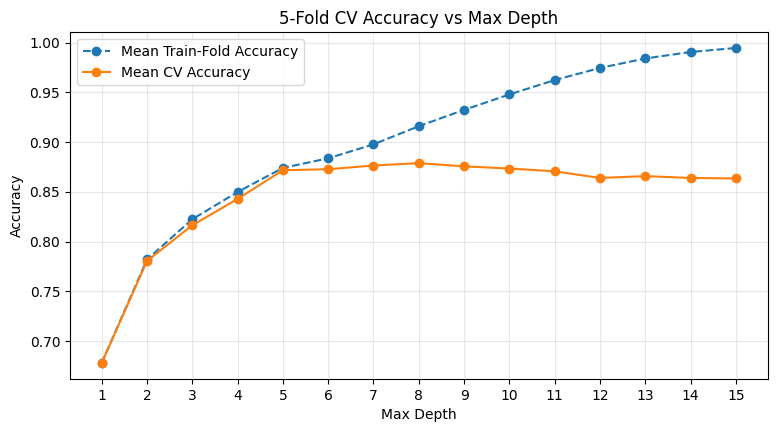

Best max_depth in the 1D CV sweep: 8 (Mean CV Accuracy: 0.8789)


In [17]:
def run_dt_1d_sweep(parameter_name, values):
    rows = []
    for value in values:
        model = DecisionTreeClassifier(random_state=RANDOM_STATE, **{parameter_name: value})
        scores = cross_validate(
            build_dt_pipeline(model),
            X_train,
            y_train_dt,
            cv=DT_CV,
            scoring="accuracy",
            return_train_score=True,
            n_jobs=-1,
        )
        rows.append(
            {
                "Value": value,
                "Mean Train-Fold Accuracy": scores["train_score"].mean(),
                "Mean CV Accuracy": scores["test_score"].mean(),
                "Std CV Accuracy": scores["test_score"].std(),
            }
        )
    return pd.DataFrame(rows)


max_depth_list = np.arange(1, 16)
max_depth_sweep = run_dt_1d_sweep("max_depth", max_depth_list)

plt.figure(figsize=(9, 4.5))
plt.plot(max_depth_sweep["Value"], max_depth_sweep["Mean Train-Fold Accuracy"], marker="o", linestyle="--", label="Mean Train-Fold Accuracy")
plt.plot(max_depth_sweep["Value"], max_depth_sweep["Mean CV Accuracy"], marker="o", label="Mean CV Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("5-Fold CV Accuracy vs Max Depth")
plt.xticks(max_depth_list)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_depth_row = max_depth_sweep.loc[max_depth_sweep["Mean CV Accuracy"].idxmax()]
best_depth = int(best_depth_row["Value"])
print(f"Best max_depth in the 1D CV sweep: {best_depth} (Mean CV Accuracy: {best_depth_row['Mean CV Accuracy']:.4f})")


<div dir="rtl" style="text-align: right;">

בסריקה החד־ממדית של `max_depth` התקבל כי עומק 8 משיג את Mean CV Accuracy הגבוה ביותר, 0.8789. ככל שהעומק גדל מעבר לאזור זה, ביצועי האימון ממשיכים להתחזק אך ממוצע הביצועים בקפלי האימות אינו משתפר בהתאם, סימן לעלייה בהתאמת היתר.

תוצאה זו היא אינדיקציה בלבד; הקונפיגורציה הסופית נבחרת בחיפוש המשולב.

</div>


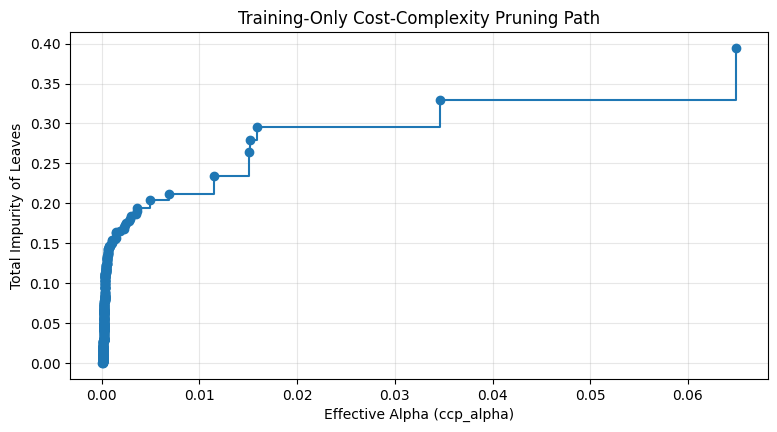

In [18]:
pruning_transformer = Pipeline(
    steps=[
        ("cleaner", AirlinePartACleaner()),
        ("preprocess", make_dt_preprocessor()),
    ]
)
X_train_preprocessed = pruning_transformer.fit_transform(X_train, y_train_dt)

clf_full_for_path = DecisionTreeClassifier(random_state=RANDOM_STATE)
clf_full_for_path.fit(X_train_preprocessed, y_train_dt)
path = clf_full_for_path.cost_complexity_pruning_path(X_train_preprocessed, y_train_dt)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
ccp_alphas_options = ccp_alphas[:-1]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ccp_alphas_options, impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("Effective Alpha (ccp_alpha)")
ax.set_ylabel("Total Impurity of Leaves")
ax.set_title("Training-Only Cost-Complexity Pruning Path")
ax.grid(alpha=0.3)
plt.show()


<div dir="rtl" style="text-align: right;">

הגרף מציג את מסלול גיזום עלות־מורכבות של עץ ההחלטה. ככל שערך `ccp_alpha` גדל, מתבצע גיזום חזק יותר של העץ: מספר הענפים והעלים קטן, והמודל הופך פשוט יותר. במקביל, סך אי־הטוהר בעלים עולה, משום שעץ פשוט יותר מבצע פחות פיצולים ולכן מתאים פחות במדויק לנתוני האימון.

גרף זה מתאר את השפעת הגיזום על מבנה העץ, אך אינו קובע לבדו את ערך `ccp_alpha` המיטבי מבחינת ביצועי אימות.

</div>

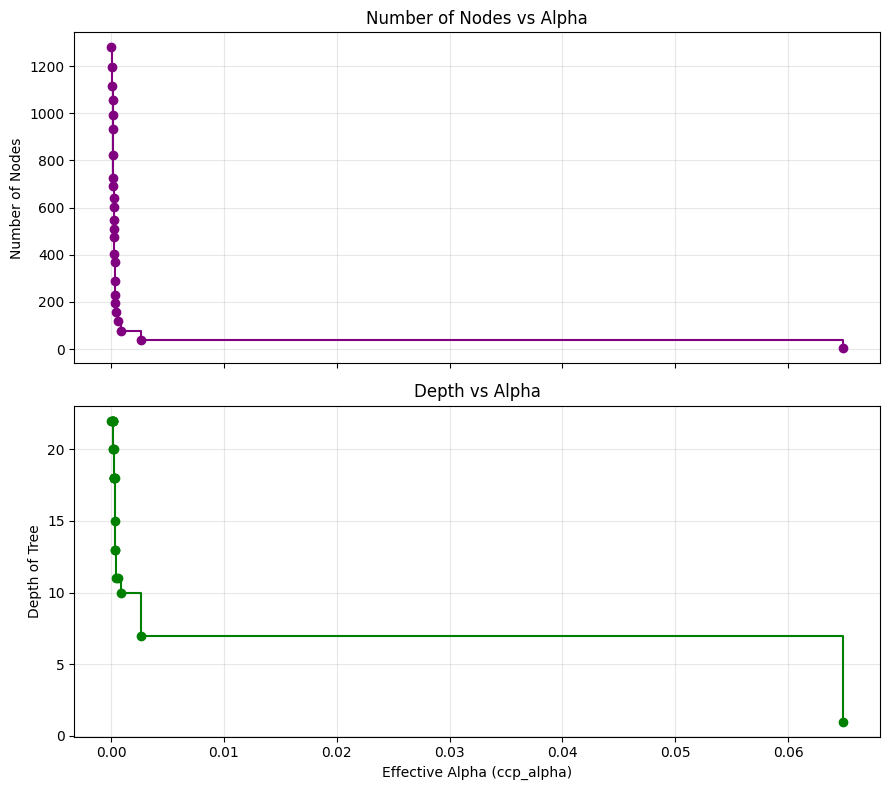

In [19]:
complexity_alphas = np.unique(
    np.percentile(ccp_alphas_options, np.linspace(0, 100, min(25, len(ccp_alphas_options))))
)
complexity_trees = []
for alpha in complexity_alphas:
    tree = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=float(alpha))
    tree.fit(X_train_preprocessed, y_train_dt)
    complexity_trees.append(tree)

node_counts = [tree.tree_.node_count for tree in complexity_trees]
depths = [tree.tree_.max_depth for tree in complexity_trees]

fig, ax = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
ax[0].plot(complexity_alphas, node_counts, marker="o", drawstyle="steps-post", color="purple")
ax[0].set_ylabel("Number of Nodes")
ax[0].set_title("Number of Nodes vs Alpha")
ax[0].grid(alpha=0.3)
ax[1].plot(complexity_alphas, depths, marker="o", drawstyle="steps-post", color="green")
ax[1].set_xlabel("Effective Alpha (ccp_alpha)")
ax[1].set_ylabel("Depth of Tree")
ax[1].set_title("Depth vs Alpha")
ax[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right;">

הגרף הבא מציג את מסלול הגיזום של העץ. ככל שערך `ccp_alpha` גדל, מתבצע גיזום חזק יותר, מספר הצמתים קטן, והעץ הופך פשוט יותר.

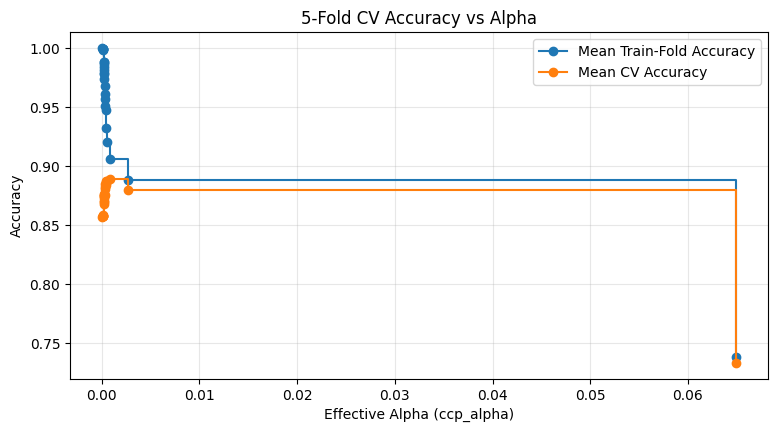

Best ccp_alpha in the 1D CV sweep: 0.000857 (Mean CV Accuracy: 0.8889)


In [20]:
ccp_sweep = run_dt_1d_sweep("ccp_alpha", complexity_alphas)

plt.figure(figsize=(9, 4.5))
plt.plot(ccp_sweep["Value"], ccp_sweep["Mean Train-Fold Accuracy"], marker="o", drawstyle="steps-post", label="Mean Train-Fold Accuracy")
plt.plot(ccp_sweep["Value"], ccp_sweep["Mean CV Accuracy"], marker="o", drawstyle="steps-post", label="Mean CV Accuracy")
plt.xlabel("Effective Alpha (ccp_alpha)")
plt.ylabel("Accuracy")
plt.title("5-Fold CV Accuracy vs Alpha")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_ccp_row = ccp_sweep.loc[ccp_sweep["Mean CV Accuracy"].idxmax()]
best_ccp_alpha = float(best_ccp_row["Value"])
print(f"Best ccp_alpha in the 1D CV sweep: {best_ccp_alpha:.6f} (Mean CV Accuracy: {best_ccp_row['Mean CV Accuracy']:.4f})")


<div dir="rtl" style="text-align: right;">

בסריקה החד־ממדית של `ccp_alpha` התקבל `ccp_alpha=0.000857`, עם Mean CV Accuracy של 0.8889. התוצאה מראה שגיזום מתון משפר את ההכללה ביחס לעץ המלא.

מסלול הגיזום נלמד מ־`X_train` בלבד, וערך זה אינו נבחר לפי סט האימות. החיפוש המשולב בוחן ערכי אלפא יחד עם יתר מנגנוני הריסון.

</div>


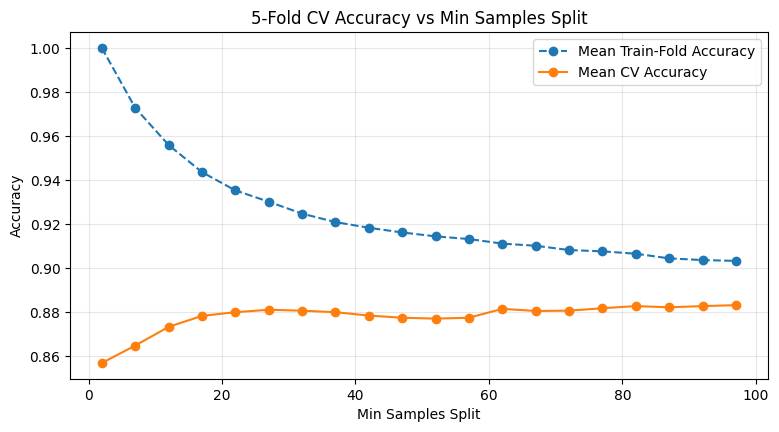

Best min_samples_split in the 1D CV sweep: 97 (Mean CV Accuracy: 0.8832)


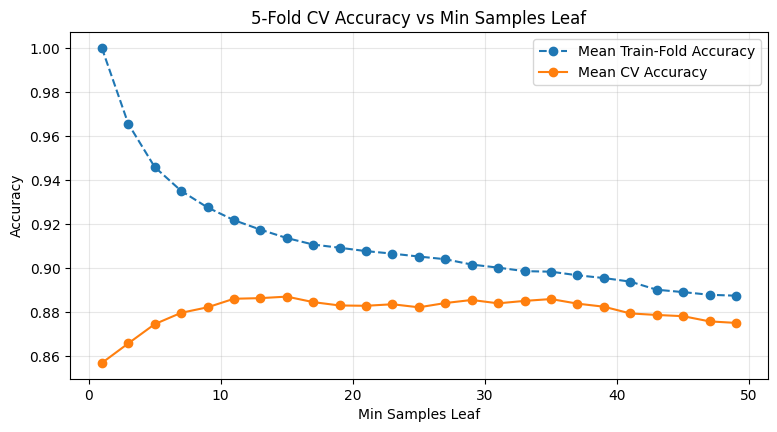

Best min_samples_leaf in the 1D CV sweep: 15 (Mean CV Accuracy: 0.8871)


In [21]:
min_samples_split_list = np.arange(2, 101, 5)
min_samples_split_sweep = run_dt_1d_sweep("min_samples_split", min_samples_split_list)

plt.figure(figsize=(9, 4.5))
plt.plot(min_samples_split_sweep["Value"], min_samples_split_sweep["Mean Train-Fold Accuracy"], marker="o", linestyle="--", label="Mean Train-Fold Accuracy")
plt.plot(min_samples_split_sweep["Value"], min_samples_split_sweep["Mean CV Accuracy"], marker="o", label="Mean CV Accuracy")
plt.xlabel("Min Samples Split")
plt.ylabel("Accuracy")
plt.title("5-Fold CV Accuracy vs Min Samples Split")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_split_row = min_samples_split_sweep.loc[min_samples_split_sweep["Mean CV Accuracy"].idxmax()]
best_split_val = int(best_split_row["Value"])
print(f"Best min_samples_split in the 1D CV sweep: {best_split_val} (Mean CV Accuracy: {best_split_row['Mean CV Accuracy']:.4f})")

min_samples_leaf_list = np.arange(1, 51, 2)
min_samples_leaf_sweep = run_dt_1d_sweep("min_samples_leaf", min_samples_leaf_list)

plt.figure(figsize=(9, 4.5))
plt.plot(min_samples_leaf_sweep["Value"], min_samples_leaf_sweep["Mean Train-Fold Accuracy"], marker="o", linestyle="--", label="Mean Train-Fold Accuracy")
plt.plot(min_samples_leaf_sweep["Value"], min_samples_leaf_sweep["Mean CV Accuracy"], marker="o", label="Mean CV Accuracy")
plt.xlabel("Min Samples Leaf")
plt.ylabel("Accuracy")
plt.title("5-Fold CV Accuracy vs Min Samples Leaf")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_leaf_row = min_samples_leaf_sweep.loc[min_samples_leaf_sweep["Mean CV Accuracy"].idxmax()]
best_leaf_val = int(best_leaf_row["Value"])
print(f"Best min_samples_leaf in the 1D CV sweep: {best_leaf_val} (Mean CV Accuracy: {best_leaf_row['Mean CV Accuracy']:.4f})")


<div dir="rtl" style="text-align: right;">

בסריקת `min_samples_split` התקבל הערך 97 עם Mean CV Accuracy של 0.8832. בסריקת `min_samples_leaf` התקבל הערך 15 עם Mean CV Accuracy של 0.8871. בשני המקרים ריסון צמתים ועלים קטנים מפחית את הנטייה של עץ מלא להתאים רעש.

הערכים המובילים בסריקות החד־ממדיות אינם מוזנים ידנית למודל הסופי; החיפוש המשולב בוחן את הרשת שהוגדרה מראש.

</div>


In [22]:
depth_options = [6, 8, 9, 10, 12]
sampled_alphas = np.unique(
    np.percentile(ccp_alphas_options, np.linspace(0, 100, 10))
).astype(float)
min_samples_split_options = [30, 60, 80, 100]
min_samples_leaf_options = [15, 25, 35, 45]

dt_param_grid = {
    "model__max_depth": depth_options,
    "model__ccp_alpha": sampled_alphas.tolist(),
    "model__min_samples_split": min_samples_split_options,
    "model__min_samples_leaf": min_samples_leaf_options,
}

dt_search = GridSearchCV(
    estimator=build_dt_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    param_grid=dt_param_grid,
    cv=DT_CV,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True,
    refit=True,
)
dt_search.fit(X_train, y_train_dt)

best_combined_depth = dt_search.best_params_["model__max_depth"]
best_combined_alpha = float(dt_search.best_params_["model__ccp_alpha"])
best_combined_split = dt_search.best_params_["model__min_samples_split"]
best_combined_leaf = dt_search.best_params_["model__min_samples_leaf"]
best_combined_cv_accuracy = float(dt_search.best_score_)

dt_search_results = (
    pd.DataFrame(dt_search.cv_results_)[
        [
            "param_model__max_depth",
            "param_model__ccp_alpha",
            "param_model__min_samples_split",
            "param_model__min_samples_leaf",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "rank_test_score",
        ]
    ]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

print("Best combined result from training-only 5-fold GridSearchCV:")
print(dt_search.best_params_)
print(f"Best Mean CV Accuracy: {best_combined_cv_accuracy:.4f}")
display(dt_search_results.head(10).round(6))


Best combined result from training-only 5-fold GridSearchCV:
{'model__ccp_alpha': 0.00038492671497453553, 'model__max_depth': 12, 'model__min_samples_leaf': 15, 'model__min_samples_split': 30}
Best Mean CV Accuracy: 0.8891


,param_model__max_depth,param_model__ccp_alpha,param_model__min_samples_split,param_model__min_samples_leaf,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,12,0.000385,30,15,0.911538,0.889134,0.005768,1
1,9,0.000319,30,15,0.907717,0.888579,0.006637,2
2,12,0.000319,30,15,0.912649,0.888162,0.005464,3
3,10,0.000319,30,15,0.910531,0.888162,0.006891,4
4,9,0.000385,30,15,0.907301,0.888023,0.006261,5
5,10,0.000385,30,15,0.909836,0.888023,0.006754,6
6,9,0.000252,30,15,0.908065,0.887745,0.005761,7
7,9,0.000201,30,15,0.908134,0.887745,0.005765,8
8,9,0.000628,80,35,0.896846,0.887468,0.007250,9
9,9,0.000628,60,35,0.896846,0.887468,0.007250,9


<div dir="rtl" style="text-align: right;">

**מסקנות מהסריקה המשולבת:**

`GridSearchCV` בחר את הקונפיגורציה `max_depth=12`, `ccp_alpha=0.000385`, `min_samples_split=30`, `min_samples_leaf=15`. Mean CV Accuracy בחמישה folds היה 0.8891.

הבחירה נעשתה בתוך סט האימון בלבד. בכל fold הותאמו מחדש `AirlinePartACleaner`, הקידוד והעץ, ללא שימוש ב־`X_valid`. רק לאחר סיום החיפוש נבדק המודל שנבחר על סט האימות.

</div>


<div dir="rtl" style="text-align: right;">


### 8.4 הרצת עץ ההחלטה המיטבי וניתוח התוצאות

עץ ההחלטה המיטבי אומן לפי שילוב הפרמטרים האופטימלי שהתקבל מסריקת הרשת המשולבת (4D Grid Search), ולאחר מכן נבחנו ביצועיו על סט האימון ועל סט האימות בהשוואה לעץ ההחלטה המלא.


</div>

Optimized Decision Tree performance after training-only tuning:


,Dataset,Accuracy,Precision,Recall,F1
0,Train,0.9132,0.9141,0.8841,0.8989
1,Validation,0.8828,0.8808,0.8461,0.8631


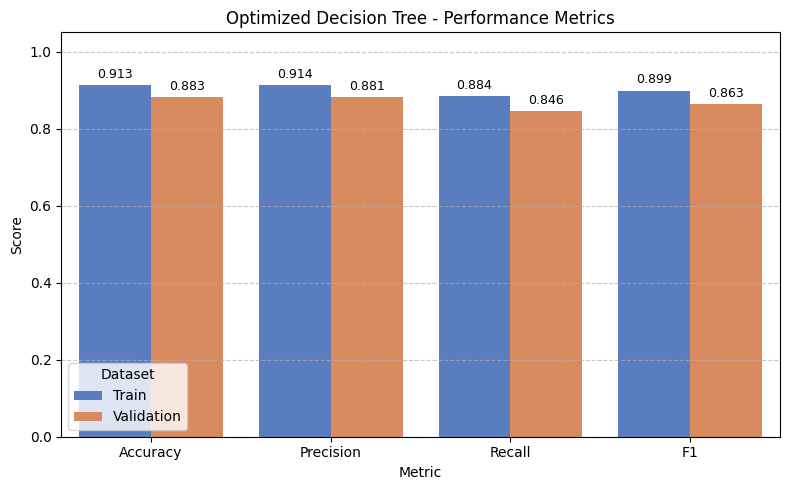

,Dataset,Accuracy,Precision,Recall,F1,Model
0,Train Fit,1.0000,1.0000,1.0000,1.0000,Full Decision Tree
1,5-Fold CV,0.8569,0.8393,0.8313,0.8352,Full Decision Tree
2,Train,0.9132,0.9141,0.8841,0.8989,Optimized Decision Tree
3,Validation,0.8828,0.8808,0.8461,0.8631,Optimized Decision Tree


In [23]:
best_dt_pipeline = dt_search.best_estimator_
best_dt_model = best_dt_pipeline.named_steps["model"]

best_dt_train_predictions = best_dt_pipeline.predict(X_train)
best_dt_valid_predictions = best_dt_pipeline.predict(X_valid)

best_dt_metrics = pd.DataFrame(
    [
        {
            "Dataset": "Train",
            "Accuracy": accuracy_score(y_train_dt, best_dt_train_predictions),
            "Precision": precision_score(y_train_dt, best_dt_train_predictions, zero_division=0),
            "Recall": recall_score(y_train_dt, best_dt_train_predictions, zero_division=0),
            "F1": f1_score(y_train_dt, best_dt_train_predictions, zero_division=0),
        },
        {
            "Dataset": "Validation",
            "Accuracy": accuracy_score(y_valid_dt, best_dt_valid_predictions),
            "Precision": precision_score(y_valid_dt, best_dt_valid_predictions, zero_division=0),
            "Recall": recall_score(y_valid_dt, best_dt_valid_predictions, zero_division=0),
            "F1": f1_score(y_valid_dt, best_dt_valid_predictions, zero_division=0),
        },
    ]
)

print("Optimized Decision Tree performance after training-only tuning:")
display(best_dt_metrics.round(4))

best_dt_plot = best_dt_metrics.melt(id_vars="Dataset", var_name="Metric", value_name="Score")
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=best_dt_plot, x="Metric", y="Score", hue="Dataset", palette="muted")
for patch in ax.patches:
    height = patch.get_height()
    if pd.notna(height) and height > 0:
        ax.annotate(
            f"{height:.3f}",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points",
        )
plt.title("Optimized Decision Tree - Performance Metrics")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

comparison_df = pd.concat(
    [
        full_dt_metrics.assign(Model="Full Decision Tree"),
        best_dt_metrics.assign(Model="Optimized Decision Tree"),
    ],
    ignore_index=True,
)
display(comparison_df.round(4))


<div dir="rtl" style="text-align: right;">

העץ המכוונן הגיע בסט האימון ל־Accuracy=0.9132, Precision=0.9141, Recall=0.8841 ו־F1=0.8989. על סט האימות התקבלו Accuracy=0.8828, Precision=0.8808, Recall=0.8461 ו־F1=0.8631.

פער ה־Accuracy בין האימון לאימות הוא 0.0304. בהשוואה לעץ המלא, שממוצע ה־CV שלו היה 0.8569 ופער ההכללה שלו היה 0.1431, הכיוונון הפחית באופן משמעותי את התאמת היתר ושיפר את ביצועי ההכללה.

</div>


<div dir="rtl" style="text-align: right;">

**תובנות ממבנה העץ:**

צומת השורש הוא `Type of Travel_Personal Travel <= 0.5`, ולכן סוג הנסיעה הוא המשתנה הראשון שמפריד בין הקבוצות. בענף של נסיעות עסקים הפיצול הבא הוא `Total_Service_Score <= 3.125`; לאחר מכן מופיעים בעיקר `Inflight wifi service`, סוג הלקוח ו־`Inflight service`.

בענף של נסיעות אישיות הפיצול הבא הוא `Inflight wifi service <= 0.5`, ובהמשך מופיעים שוב דירוג ה־wifi ו־`Ease of Online booking`. המבנה תומך במסקנה שהמודל משלב את הקשר הנסיעה עם איכות השירות הכוללת ועם שירותים נקודתיים.

</div>


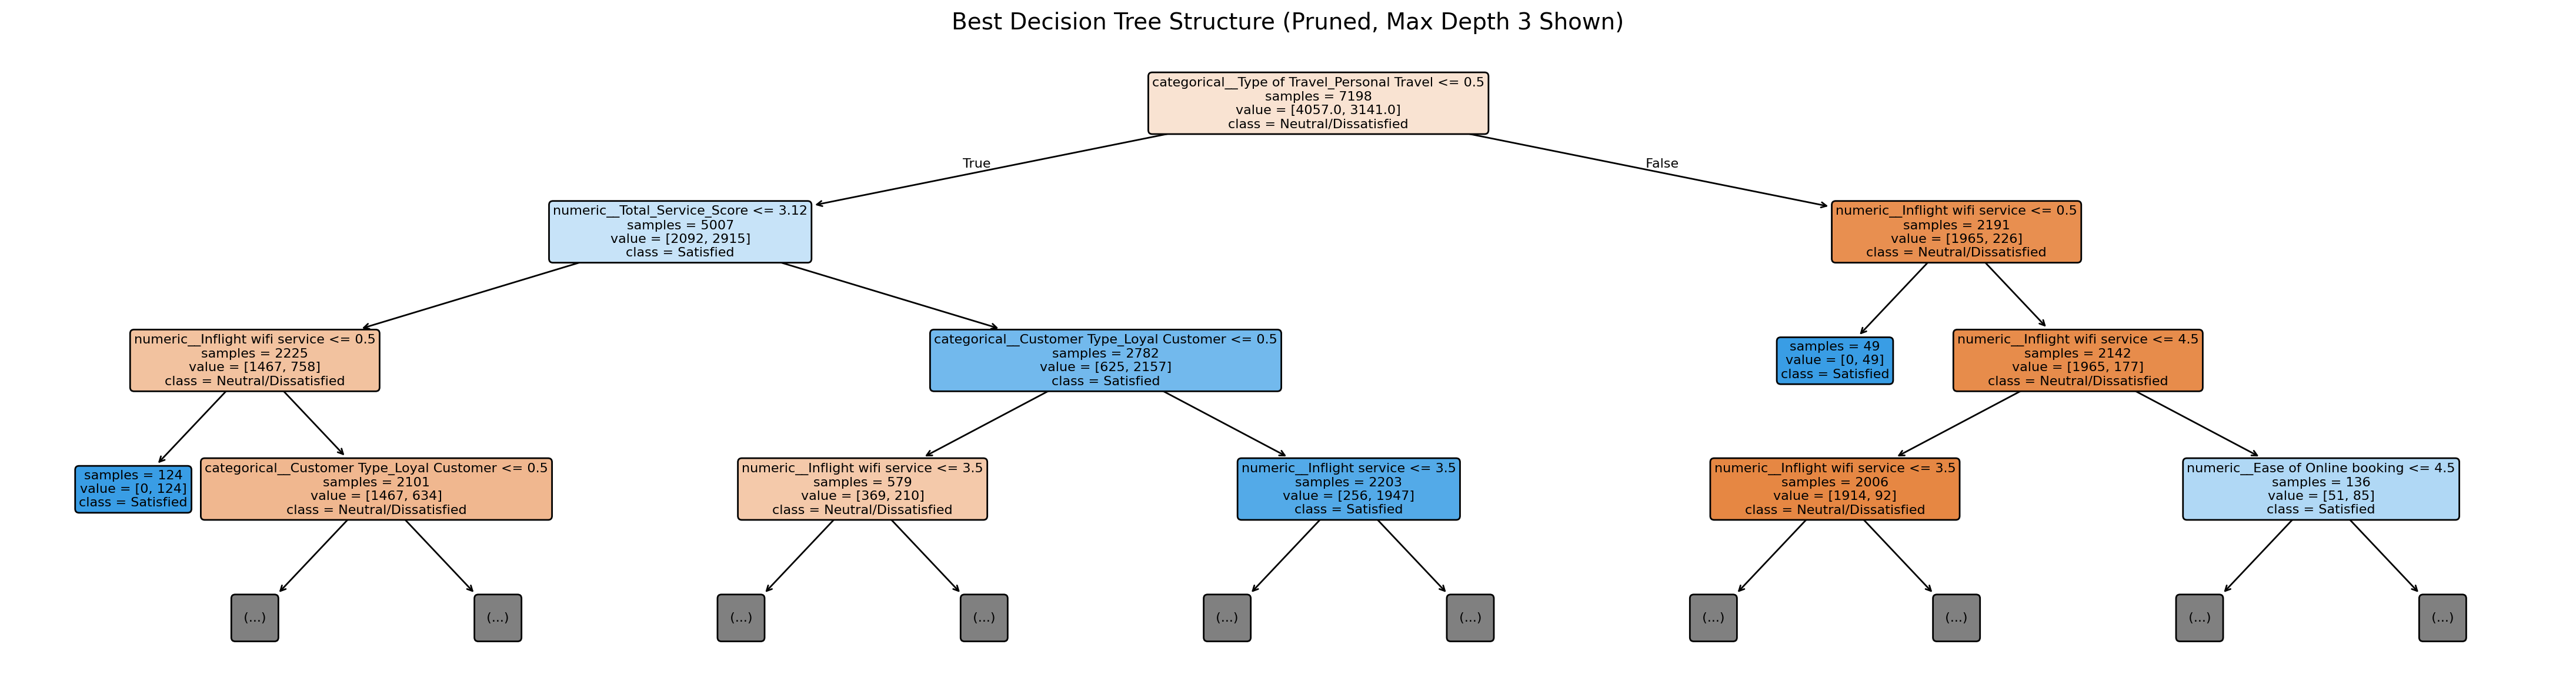

<Figure size 900x750 with 0 Axes>

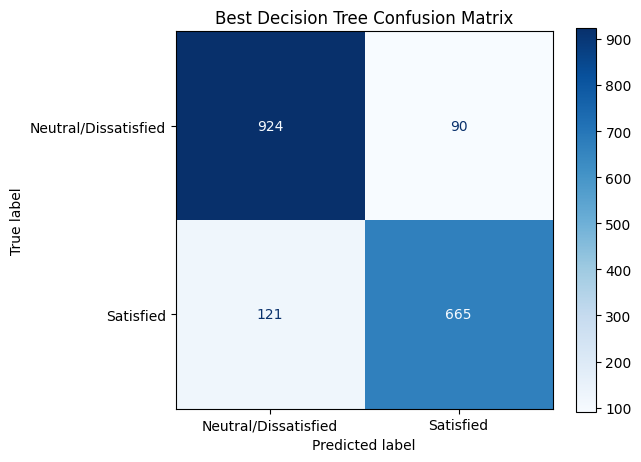

In [24]:
preprocessed_feature_names = best_dt_pipeline.named_steps["preprocess"].get_feature_names_out()

plt.figure(figsize=(22, 6), dpi=200)
plot_tree(
    best_dt_pipeline.named_steps["model"],
    max_depth=3,
    feature_names=preprocessed_feature_names,
    class_names=["Neutral/Dissatisfied", "Satisfied"],
    filled=True,
    rounded=True,
    fontsize=8,
    impurity=False,
    proportion=False,
    precision=2,
)
plt.title("Best Decision Tree Structure (Pruned, Max Depth 3 Shown)", fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5), dpi=150)
ConfusionMatrixDisplay.from_predictions(
    y_valid_dt,
    best_dt_valid_predictions,
    display_labels=["Neutral/Dissatisfied", "Satisfied"],
    cmap="Blues",
    values_format="d",
)
plt.title("Best Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()


In [25]:
sample_idx = 10
sample_features = X_valid.iloc[[sample_idx]]
sample_true_label = y_valid_dt.iloc[sample_idx]

display(sample_features.T.rename(columns={sample_features.index[0]: "Feature Value"}))
print(f"True Label: {sample_true_label} ({'Satisfied' if sample_true_label == 1 else 'Neutral/Dissatisfied'})")

sample_pred = best_dt_pipeline.predict(sample_features)[0]
print(f"Model Prediction: {sample_pred} ({'Satisfied' if sample_pred == 1 else 'Neutral/Dissatisfied'})")

cleaner = best_dt_pipeline.named_steps["cleaner"]
preprocessor = best_dt_pipeline.named_steps["preprocess"]
tree_model = best_dt_pipeline.named_steps["model"]

sample_cleaned = cleaner.transform(sample_features)
sample_processed = preprocessor.transform(sample_cleaned)

node_indicator = tree_model.decision_path(sample_processed)
leaf_id = tree_model.apply(sample_processed)[0]
tree = tree_model.tree_
decision_path_lines = []

print("\nDecision path for selected sample:")
for node_id in node_indicator.indices:
    if node_id == leaf_id:
        line = f"Reached leaf node {node_id}."
        decision_path_lines.append(line)
        print(line)
        break

    feature_idx = tree.feature[node_id]
    threshold = tree.threshold[node_id]
    feature_name = preprocessed_feature_names[feature_idx]
    feature_value = sample_processed[0, feature_idx]

    if feature_value <= threshold:
        direction, condition = "left", "<="
    else:
        direction, condition = "right", ">"

    line = (
        f"Node {node_id}: {feature_name} = {feature_value:.3f} "
        f"{condition} {threshold:.3f} -> go {direction}"
    )
    decision_path_lines.append(line)
    print(line)

print("\nSummary for report:")
print("Position in validation set:", sample_idx)
print("Original row index:", sample_features.index[0])
print(f"Prediction: {'Satisfied' if sample_pred == 1 else 'Neutral/Dissatisfied'}")
print(f"True value: {'Satisfied' if sample_true_label == 1 else 'Neutral/Dissatisfied'}")
print(f"Correct classification: {'Yes' if sample_pred == sample_true_label else 'No'}")


,Feature Value
Gender,Male
Customer Type,Loyal Customer
Age,38.0
Type of Travel,Business travel
Class,Business
Flight Distance,3733.0
Plane colors,3
Inflight wifi service,3.0
Departure/Arrival time convenient,1.0
Ease of Online booking,1.0


True Label: 1 (Satisfied)
Model Prediction: 1 (Satisfied)

Decision path for selected sample:
Node 0: categorical__Type of Travel_Personal Travel = 0.000 <= 0.500 -> go left
Node 1: numeric__Total_Service_Score = 2.750 <= 3.125 -> go left
Node 2: numeric__Inflight wifi service = 3.000 > 0.500 -> go right
Node 4: categorical__Customer Type_Loyal Customer = 1.000 > 0.500 -> go right
Node 14: numeric__Cleanliness = 4.000 > 3.500 -> go right
Node 44: numeric__Cleanliness = 4.000 <= 4.500 -> go left
Node 45: numeric__Inflight service = 4.000 > 3.500 -> go right
Node 59: numeric__Seat comfort = 1.000 <= 3.500 -> go left
Node 60: numeric__On-board service = 4.000 > 2.500 -> go right
Reached leaf node 62.

Summary for report:
Position in validation set: 10
Original row index: 4267
Prediction: Satisfied
True value: Satisfied
Correct classification: Yes


<div dir="rtl" style="text-align: right;">

**תיאור מעבר ידני עבור הרשומה שנבחרה:**

נבחרה הרשומה במיקום 10 בסט האימות, אינדקס מקורי 4267. מדובר בנוסע זכר, לקוח נאמן, בן 38, בנסיעת עסקים ובמחלקת Business. תחזית העץ והערך האמיתי הם `Satisfied`.

מסלול ההחלטה היה:
1. `Type of Travel_Personal Travel=0 <= 0.500` ולכן מעבר שמאלה.
2. `Total_Service_Score=2.750 <= 3.125` ולכן מעבר שמאלה.
3. `Inflight wifi service=3.000 > 0.500` ולכן מעבר ימינה.
4. `Customer Type_Loyal Customer=1.000 > 0.500` ולכן מעבר ימינה.
5. `Cleanliness=4.000 > 3.500` ולכן מעבר ימינה.
6. `Cleanliness=4.000 <= 4.500` ולכן מעבר שמאלה.
7. `Inflight service=4.000 > 3.500` ולכן מעבר ימינה.
8. `Seat comfort=1.000 <= 3.500` ולכן מעבר שמאלה.
9. `On-board service=4.000 > 2.500` ולכן מעבר ימינה.
10. הרשומה הגיעה לעלה 62 וסווגה נכון כ־`Satisfied`.

</div>


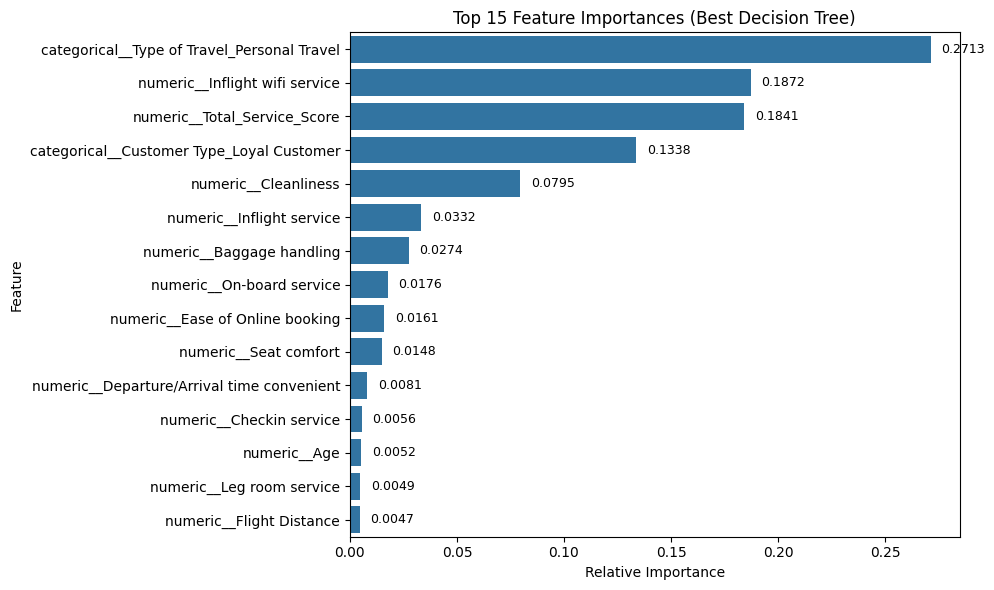

Rank,Feature,Importance
1,categorical__Type of Travel_Personal Travel,0.271300
2,numeric__Inflight wifi service,0.187200
3,numeric__Total_Service_Score,0.184100
4,categorical__Customer Type_Loyal Customer,0.133800
5,numeric__Cleanliness,0.079500


In [26]:
best_dt_model = best_dt_pipeline.named_steps["model"]
importances = best_dt_model.feature_importances_
indices = np.argsort(importances)[::-1]

feature_importance_df = pd.DataFrame(
    {
        "Feature": preprocessed_feature_names[indices],
        "Importance": importances[indices],
    }
)
top_15_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Importance", y="Feature", data=top_15_features)
ax.set_title("Top 15 Feature Importances (Best Decision Tree)")
ax.set_xlabel("Relative Importance")
ax.set_ylabel("Feature")
for patch in ax.patches:
    width = patch.get_width()
    if pd.notna(width) and width > 0:
        ax.text(width + 0.005, patch.get_y() + patch.get_height() / 2, f"{width:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

top_5_feature_importance = feature_importance_df.head(5).reset_index(drop=True)
top_5_feature_importance.insert(0, "Rank", range(1, 6))
display(top_5_feature_importance.round(4).style.hide(axis="index"))


<div dir="rtl" style="text-align: right;">

**ניתוח חשיבות משתנים והשוואה לחלק א':**

חמשת המאפיינים החשובים ביותר בעץ המכוונן הם:
1. `Type of Travel_Personal Travel` עם חשיבות 0.2713.
2. `Inflight wifi service` עם חשיבות 0.1872.
3. `Total_Service_Score` עם חשיבות 0.1841.
4. `Customer Type_Loyal Customer` עם חשיבות 0.1338.
5. `Cleanliness` עם חשיבות 0.0795.

הדירוג מתיישב עם התובנות מחלק א׳: סוג הנסיעה, איכות השירות הכוללת, ה־wifi, נאמנות הלקוח והניקיון הם גורמים מרכזיים. החשיבות היא יחסית לעץ שנבנה ואינה מוכיחה קשר סיבתי.

</div>


<div dir="rtl" style="text-align: right;">

## 9. רשתות נוירונים / MLP

בסעיף זה נבחן מודל רשת נוירונים מסוג MLP לסיווג שביעות רצון נוסעים. תחילה נמפה את משתנה המטרה לערכים בינאריים ונבצע עיבוד מקדים בתוך Pipeline כדי למנוע דליפת מידע. לאחר מכן נאמן מודל MLP בסיסי, נבצע כיוונון ארכיטקטורות באמצעות GridSearchCV, ונשווה בין מודל ברירת המחדל לבין המודל שנבחר.

</div>


<div dir="rtl" style="text-align: right;">

### 9.1 הכנת הנתונים לרשת נוירונים

ה־Pipeline של ה־MLP כולל `AirlinePartACleaner`, קידוד One-Hot למשתנים הקטגוריאליים ו־`StandardScaler` למשתנים המספריים. selectors דינמיים מזהים את סוגי העמודות לאחר הניקוי. כל שלבי ההתאמה מתבצעים מחדש בתוך כל fold, ולכן חציונים, שכיחים, קטגוריות ופרמטרי סקיילינג אינם נלמדים מ־`X_valid` או מ־`X_test`.

Accuracy הוא מדד ראשי סביר משום שהתפלגות המחלקות היא בקירוב 56% מול 44%, אך כדי לוודא שהמודל אינו מסתיר חולשה במחלקה החיובית מדווחים גם Precision, Recall ו־F1.

</div>


In [27]:
from IPython.display import Markdown
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

CLASS_LABELS_MLP = [0, 1]
CLASS_NAMES_MLP = ["Neutral/Dissatisfied", "Satisfied"]
MLP_SCORING = "accuracy"
MLP_CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
MLP_SCORING_SET = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

y_train_mlp = y_train.map(TARGET_MAP)
y_valid_mlp = y_valid.map(TARGET_MAP)

if y_train_mlp.isna().any() or y_valid_mlp.isna().any():
    raise ValueError("The target contains values that are not defined in the binary mapping.")

y_train_mlp = y_train_mlp.astype(int)
y_valid_mlp = y_valid_mlp.astype(int)

display(pd.DataFrame({"Original Value": list(TARGET_MAP.keys()), "Binary Value": list(TARGET_MAP.values())}))
print("MLP tuning uses 3 shuffled stratified folds as a stability/runtime compromise.")


,Original Value,Binary Value
0,neutral or dissatisfied,0
1,satisfied,1


MLP tuning uses 3 shuffled stratified folds as a stability/runtime compromise.


In [28]:
def make_mlp_preprocessor():
    numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
    categorical_transformer = Pipeline(steps=[("encoder", make_one_hot_encoder())])
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_selector),
            ("categorical", categorical_transformer, categorical_selector),
        ],
        remainder="drop",
    )


def build_mlp_pipeline(model):
    return Pipeline(
        steps=[
            ("cleaner", AirlinePartACleaner()),
            ("preprocess", make_mlp_preprocessor()),
            ("model", model),
        ]
    )


def evaluate_mlp_model(model_name, fitted_model):
    rows = []
    for split_name, X_data, y_true in [
        ("Train", X_train, y_train_mlp),
        ("Validation", X_valid, y_valid_mlp),
    ]:
        y_pred = fitted_model.predict(X_data)
        rows.append(
            {
                "Model": model_name,
                "Set": split_name,
                "Accuracy": accuracy_score(y_true, y_pred),
                "Precision": precision_score(y_true, y_pred, zero_division=0),
                "Recall": recall_score(y_true, y_pred, zero_division=0),
                "F1": f1_score(y_true, y_pred, zero_division=0),
            }
        )
    return pd.DataFrame(rows)


def get_mlp_input_size(fitted_pipeline):
    cleaned = fitted_pipeline.named_steps["cleaner"].transform(X_train.iloc[:1])
    return fitted_pipeline.named_steps["preprocess"].transform(cleaned).shape[1]


def normalize_hidden_layers(hidden_layer_sizes):
    if isinstance(hidden_layer_sizes, int):
        return (hidden_layer_sizes,)
    return tuple(hidden_layer_sizes)


def describe_mlp_configuration(fitted_pipeline):
    hidden_layers = normalize_hidden_layers(fitted_pipeline.named_steps["model"].hidden_layer_sizes)
    return pd.DataFrame(
        {
            "Component": [
                "Input Layer Neurons",
                "Number of Hidden Layers",
                "Neurons per Hidden Layer",
                "Total Hidden Neurons",
                "Output Layer",
            ],
            "Value": [
                get_mlp_input_size(fitted_pipeline),
                len(hidden_layers),
                str(hidden_layers),
                sum(hidden_layers),
                "Binary classification: 0 or 1",
            ],
        }
    )


numeric_features_mlp = numeric_features_dt
categorical_features_mlp = categorical_features_dt
mlp_preprocessing_summary = pd.DataFrame(
    {
        "Variable Type": ["Numeric", "Categorical"],
        "Number of Variables": [len(numeric_features_mlp), len(categorical_features_mlp)],
        "Preprocessing Operation": ["StandardScaler", "One-Hot Encoding"],
    }
)
display(mlp_preprocessing_summary)


,Variable Type,Number of Variables,Preprocessing Operation
0,Numeric,17,StandardScaler
1,Categorical,6,One-Hot Encoding


<div dir="rtl" style="text-align: right;">

### 9.2 רשת נוירונים בערכי ברירת מחדל

לאחר העיבוד המקדים מתקבלים 33 מאפייני קלט. מודל ברירת המחדל, עם שכבה חבויה אחת בת 100 נוירונים, הגיע בהתאמה לסט האימון ל־Accuracy=0.9931, Precision=0.9924, Recall=0.9917 ו־F1=0.9920. ב־3-fold Cross-Validation התקבלו בממוצע Accuracy=0.8808, Precision=0.8714, Recall=0.8529 ו־F1=0.8619.

פער של כ־0.1123 בין התאמת האימון לבין ממוצע ה־CV מעיד על התאמת יתר. בנוסף התקבלה אזהרה שהאופטימייזר הגיע ל־500 איטרציות בלי התכנסות מלאה, ולכן מודל זה משמש נקודת בסיס ולא מועמד סופי.

</div>


In [29]:
default_mlp_pipeline = build_mlp_pipeline(
    MLPClassifier(random_state=RANDOM_STATE, max_iter=500)
)

default_mlp_cv = cross_validate(
    default_mlp_pipeline,
    X_train,
    y_train_mlp,
    cv=MLP_CV,
    scoring=MLP_SCORING_SET,
    return_train_score=True,
    n_jobs=-1,
)
default_mlp_pipeline.fit(X_train, y_train_mlp)
default_mlp_train_predictions = default_mlp_pipeline.predict(X_train)

default_mlp_metrics = pd.DataFrame(
    [
        {
            "Model": "Default MLP",
            "Set": "Train Fit",
            "Accuracy": accuracy_score(y_train_mlp, default_mlp_train_predictions),
            "Precision": precision_score(y_train_mlp, default_mlp_train_predictions, zero_division=0),
            "Recall": recall_score(y_train_mlp, default_mlp_train_predictions, zero_division=0),
            "F1": f1_score(y_train_mlp, default_mlp_train_predictions, zero_division=0),
        },
        {
            "Model": "Default MLP",
            "Set": "3-Fold CV",
            "Accuracy": default_mlp_cv["test_accuracy"].mean(),
            "Precision": default_mlp_cv["test_precision"].mean(),
            "Recall": default_mlp_cv["test_recall"].mean(),
            "F1": default_mlp_cv["test_f1"].mean(),
        },
    ]
)
display(default_mlp_metrics.round(4))
default_mlp_architecture = describe_mlp_configuration(default_mlp_pipeline)
display(default_mlp_architecture)


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Set,Accuracy,Precision,Recall,F1
0,Default MLP,Train Fit,0.9931,0.9924,0.9917,0.9920
1,Default MLP,3-Fold CV,0.8808,0.8714,0.8529,0.8619


,Component,Value
0,Input Layer Neurons,33
1,Number of Hidden Layers,1
2,Neurons per Hidden Layer,"(100,)"
3,Total Hidden Neurons,100
4,Output Layer,Binary classification: 0 or 1


<div dir="rtl" style="text-align: right;">

### 9.3 השוואת ארכיטקטורות לרשת הנוירונים

החיפוש בוצע באמצעות `GridSearchCV` עם `StratifiedKFold(n_splits=3, shuffle=True, random_state=42)`. שלושה folds הם פשרה בין יציבות ההערכה לבין זמן האימון, ובכל fold מותאמים מחדש הניקוי, הקידוד והסטנדרטיזציה.

הקונפיגורציה המובילה היא שלוש שכבות חבויות בגודל `(50, 25, 10)`, עם 85 נוירונים חבויים בסך הכול, `alpha=0.001`, הפעלה `relu` וקצב למידה 0.001. Mean CV Accuracy היה 0.8927. הפערים בין מספר קונפיגורציות מובילות קטנים, ולכן אין עדות ליתרון גדול של ארכיטקטורה אחת.

</div>


In [30]:
architecture_options_mlp = [
    (25,),
    (50,),
    (100,),
    (150,),
    (50, 25),
    (100, 50),
    (150, 75),
    (200, 100),
    (50, 25, 10),
    (100, 50, 25),
]

mlp_search_pipeline = build_mlp_pipeline(
    MLPClassifier(
        random_state=RANDOM_STATE,
        max_iter=300,
        early_stopping=True,
        n_iter_no_change=10,
    )
)

param_grid_mlp = {
    "model__hidden_layer_sizes": architecture_options_mlp,
    "model__activation": ["relu"],
    "model__alpha": [0.0001, 0.001],
    "model__learning_rate_init": [0.001],
}

mlp_search = GridSearchCV(
    estimator=mlp_search_pipeline,
    param_grid=param_grid_mlp,
    cv=MLP_CV,
    scoring=MLP_SCORING,
    n_jobs=-1,
    return_train_score=True,
    refit=True,
)
mlp_search.fit(X_train, y_train_mlp)

mlp_tuning_results = pd.DataFrame(mlp_search.cv_results_).copy()
mlp_tuning_results["hidden_layer_sizes"] = mlp_tuning_results["param_model__hidden_layer_sizes"].apply(normalize_hidden_layers)
mlp_tuning_results["number_of_hidden_layers"] = mlp_tuning_results["hidden_layer_sizes"].apply(len)
mlp_tuning_results["total_hidden_neurons"] = mlp_tuning_results["hidden_layer_sizes"].apply(sum)
mlp_tuning_results["architecture_order"] = mlp_tuning_results["hidden_layer_sizes"].apply(architecture_options_mlp.index)

mlp_tuning_table = (
    mlp_tuning_results[
        [
            "hidden_layer_sizes",
            "number_of_hidden_layers",
            "total_hidden_neurons",
            "mean_test_score",
            "std_test_score",
            "rank_test_score",
            "param_model__alpha",
            "param_model__learning_rate_init",
            "param_model__activation",
            "mean_train_score",
            "architecture_order",
        ]
    ]
    .rename(
        columns={
            "number_of_hidden_layers": "number of hidden layers",
            "total_hidden_neurons": "total hidden neurons",
            "mean_test_score": "mean CV accuracy",
            "std_test_score": "std CV accuracy",
            "param_model__alpha": "alpha",
            "param_model__learning_rate_init": "learning_rate_init",
            "param_model__activation": "activation",
            "mean_train_score": "mean train accuracy",
        }
    )
    .sort_values(["rank_test_score", "architecture_order", "alpha"])
    .reset_index(drop=True)
)
display(mlp_tuning_table.drop(columns=["architecture_order"]).round(4))


,hidden_layer_sizes,number of hidden layers,total hidden neurons,mean CV accuracy,std CV accuracy,rank_test_score,alpha,learning_rate_init,activation,mean train accuracy
0,"(50, 25, 10)",3,85,0.8927,0.0017,1,0.0010,0.001,relu,0.9166
1,"(150,)",1,150,0.8923,0.0036,2,0.0001,0.001,relu,0.9123
2,"(100, 50)",2,150,0.8918,0.0023,3,0.0010,0.001,relu,0.9162
3,"(100, 50)",2,150,0.8918,0.0014,4,0.0001,0.001,relu,0.9178
4,"(50, 25, 10)",3,85,0.8916,0.0010,5,0.0001,0.001,relu,0.9161
5,"(100,)",1,100,0.8915,0.0032,6,0.0001,0.001,relu,0.9137
6,"(100,)",1,100,0.8911,0.0030,7,0.0010,0.001,relu,0.9137
7,"(150,)",1,150,0.8909,0.0016,8,0.0010,0.001,relu,0.9055
8,"(50, 25)",2,75,0.8907,0.0032,9,0.0001,0.001,relu,0.9158
9,"(50, 25)",2,75,0.8904,0.0028,10,0.0010,0.001,relu,0.9166


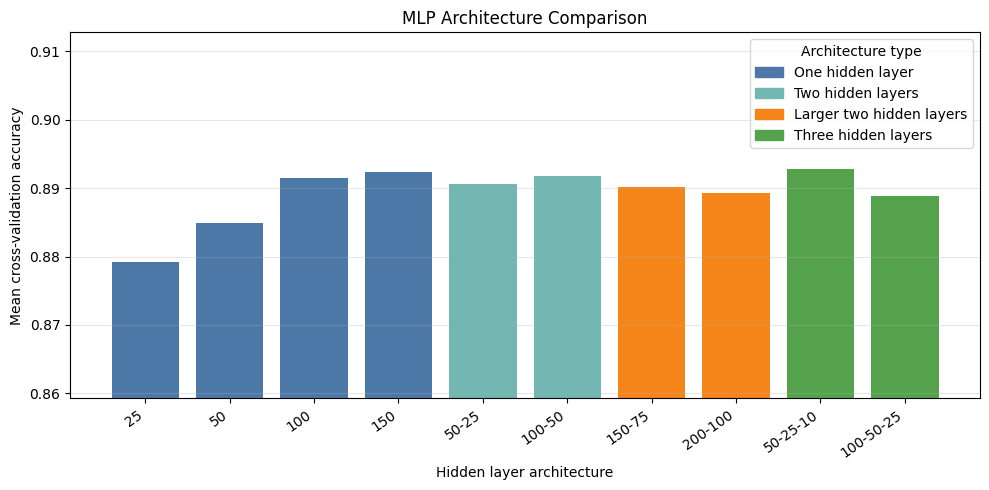

In [31]:
def get_architecture_group(hidden_layer_sizes):
    if len(hidden_layer_sizes) == 1:
        return "One hidden layer"
    if len(hidden_layer_sizes) == 3:
        return "Three hidden layers"
    if sum(hidden_layer_sizes) >= 225:
        return "Larger two hidden layers"
    return "Two hidden layers"


architecture_plot_data = (
    mlp_tuning_table.sort_values("rank_test_score")
    .drop_duplicates(subset=["hidden_layer_sizes"])
    .sort_values("architecture_order")
    .reset_index(drop=True)
)
architecture_plot_data["architecture label"] = architecture_plot_data[
    "hidden_layer_sizes"
].apply(lambda layers: "-".join(map(str, layers)))
architecture_plot_data["architecture group"] = architecture_plot_data[
    "hidden_layer_sizes"
].apply(get_architecture_group)

architecture_colors = {
    "One hidden layer": "#4C78A8",
    "Two hidden layers": "#72B7B2",
    "Larger two hidden layers": "#F58518",
    "Three hidden layers": "#54A24B",
}
bar_colors = architecture_plot_data["architecture group"].map(architecture_colors)

plt.figure(figsize=(10, 5))
plt.bar(
    architecture_plot_data["architecture label"],
    architecture_plot_data["mean CV accuracy"],
    color=bar_colors,
)
plt.xlabel("Hidden layer architecture")
plt.ylabel("Mean cross-validation accuracy")
plt.title("MLP Architecture Comparison")
plt.xticks(rotation=35, ha="right")
plt.ylim(
    max(0, architecture_plot_data["mean CV accuracy"].min() - 0.02),
    min(1, architecture_plot_data["mean CV accuracy"].max() + 0.02),
)
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=label)
    for label, color in architecture_colors.items()
]
plt.legend(handles=legend_handles, title="Architecture type")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">

### 9.4 הרצת הרשת הנבחרת וניתוח התוצאות

ה־MLP המכוונן הגיע בסט האימון ל־Accuracy=0.9398, Precision=0.9436, Recall=0.9169 ו־F1=0.9301. על סט האימות התקבלו Accuracy=0.8828, Precision=0.8778, Recall=0.8499 ו־F1=0.8636.

פער ה־Accuracy בין האימון לאימות הוא 0.0571. ה־CV של המודל שנבחר גבוה מזה של מודל ברירת המחדל, אך תוצאת האימות השמורה דומה, ולכן השיפור בפועל מתון.

</div>


In [32]:
best_mlp_pipeline = mlp_search.best_estimator_
best_mlp_params = mlp_search.best_params_
best_hidden_layers = normalize_hidden_layers(best_mlp_params["model__hidden_layer_sizes"])

best_mlp_metrics = evaluate_mlp_model("Tuned MLP", best_mlp_pipeline)

best_mlp_params_table = pd.DataFrame(
    {
        "Parameter": [
            "hidden_layer_sizes",
            "number of hidden layers",
            "total hidden neurons",
            "activation",
            "alpha",
            "learning_rate_init",
            "best mean CV accuracy",
        ],
        "Selected Value": [
            str(best_hidden_layers),
            len(best_hidden_layers),
            sum(best_hidden_layers),
            best_mlp_params["model__activation"],
            best_mlp_params["model__alpha"],
            best_mlp_params["model__learning_rate_init"],
            round(mlp_search.best_score_, 4),
        ],
    }
)

best_mlp_architecture = describe_mlp_configuration(best_mlp_pipeline)
display(best_mlp_params_table)
display(best_mlp_architecture)
display(best_mlp_metrics.round(4))


,Parameter,Selected Value
0,hidden_layer_sizes,"(50, 25, 10)"
1,number of hidden layers,3
2,total hidden neurons,85
3,activation,relu
4,alpha,0.001
5,learning_rate_init,0.001
6,best mean CV accuracy,0.8927


,Component,Value
0,Input Layer Neurons,33
1,Number of Hidden Layers,3
2,Neurons per Hidden Layer,"(50, 25, 10)"
3,Total Hidden Neurons,85
4,Output Layer,Binary classification: 0 or 1


,Model,Set,Accuracy,Precision,Recall,F1
0,Tuned MLP,Train,0.9398,0.9436,0.9169,0.9301
1,Tuned MLP,Validation,0.8828,0.8778,0.8499,0.8636


Validation classification report for the selected MLP:
                      precision    recall  f1-score   support

Neutral/Dissatisfied       0.89      0.91      0.90      1014
           Satisfied       0.88      0.85      0.86       786

            accuracy                           0.88      1800
           macro avg       0.88      0.88      0.88      1800
        weighted avg       0.88      0.88      0.88      1800



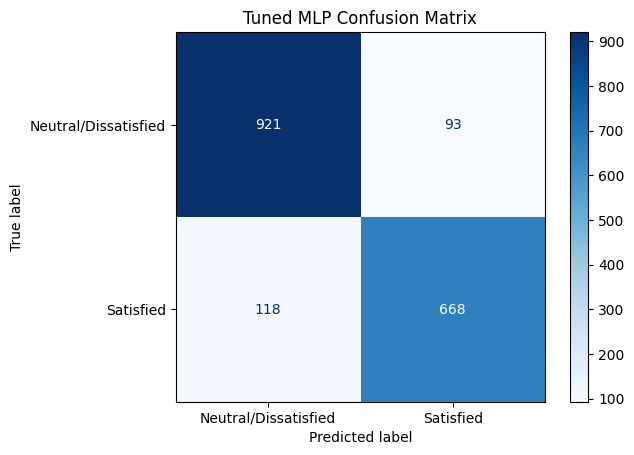

In [33]:
best_mlp_valid_predictions = best_mlp_pipeline.predict(X_valid)

print("Validation classification report for the selected MLP:")
print(
    classification_report(
        y_valid_mlp,
        best_mlp_valid_predictions,
        labels=CLASS_LABELS_MLP,
        target_names=CLASS_NAMES_MLP,
        zero_division=0,
    )
)


ConfusionMatrixDisplay.from_predictions(
    y_valid_mlp,
    best_mlp_valid_predictions,
    display_labels=["Neutral/Dissatisfied", "Satisfied"],
    cmap="Blues",
    values_format="d",
)
plt.title("Tuned MLP Confusion Matrix")
plt.show()

<div dir="rtl" style="text-align: right;">

מטריצת הבלבול של ה־MLP המכוונן כוללת 921 True Negatives ו־668 True Positives. בנוסף נרשמו 93 False Positives ו־118 False Negatives.

המודל מסווג נכון את רוב התצפיות בשתי המחלקות, אך מתקשה מעט יותר בזיהוי נוסעים מרוצים: Recall המחלקה החיובית הוא 0.8499.

</div>


In [34]:
default_cv_accuracy = default_mlp_metrics.loc[
    default_mlp_metrics["Set"] == "3-Fold CV", "Accuracy"
].iloc[0]
best_train_accuracy = best_mlp_metrics.loc[
    best_mlp_metrics["Set"] == "Train", "Accuracy"
].iloc[0]
best_valid_accuracy = best_mlp_metrics.loc[
    best_mlp_metrics["Set"] == "Validation", "Accuracy"
].iloc[0]
generalization_gap = best_train_accuracy - best_valid_accuracy

mlp_conclusion = (
    f"The default MLP achieved mean 3-fold CV Accuracy={default_cv_accuracy:.4f}. "
    f"GridSearchCV selected architecture {best_hidden_layers} with mean CV Accuracy={mlp_search.best_score_:.4f}. "
    f"After tuning was complete, the selected model achieved validation Accuracy={best_valid_accuracy:.4f}. "
    f"Its train-validation Accuracy gap is {generalization_gap:.4f}."
)
display(Markdown(mlp_conclusion))


The default MLP achieved mean 3-fold CV Accuracy=0.8808. GridSearchCV selected architecture (50, 25, 10) with mean CV Accuracy=0.8927. After tuning was complete, the selected model achieved validation Accuracy=0.8828. Its train-validation Accuracy gap is 0.0571.

<div dir="rtl" style="text-align: right;">

## 10. השוואה בין מודלים

ההשוואה מתבצעת בין עץ ההחלטה וה־MLP לאחר שכל אחד כוונן בתוך סט האימון בלבד. המדד הראשי לבחירה הוא Validation Accuracy; Precision, Recall, F1, פער ההכללה ויכולת הפרשנות משמשים להסבר משלים.

Accuracy מתאים כמדד ראשי משום שהמחלקות אינן בלתי־מאוזנות באופן קיצוני, אך המדדים הנוספים נדרשים כדי לזהות חולשה אפשרית בזיהוי נוסעים מרוצים. בהתאם לעדכון המרצה המתועד ב־`CONTEXT.md`, K-Means ו־Naive Bayes הוסרו מהיקף החובה ואינם חלק מההשוואה.

</div>


In [35]:
dt_train_row = best_dt_metrics.loc[best_dt_metrics["Dataset"] == "Train"].iloc[0]
dt_valid_row = best_dt_metrics.loc[best_dt_metrics["Dataset"] == "Validation"].iloc[0]
mlp_train_row = best_mlp_metrics.loc[best_mlp_metrics["Set"] == "Train"].iloc[0]
mlp_valid_row = best_mlp_metrics.loc[best_mlp_metrics["Set"] == "Validation"].iloc[0]

dt_gap = dt_train_row["Accuracy"] - dt_valid_row["Accuracy"]
mlp_gap = mlp_train_row["Accuracy"] - mlp_valid_row["Accuracy"]

dt_configuration = (
    f"max_depth={best_combined_depth}, ccp_alpha={best_combined_alpha:.6f}, "
    f"min_samples_split={best_combined_split}, min_samples_leaf={best_combined_leaf}"
)

model_comparison_table = pd.DataFrame(
    [
        {
            "Model": "Decision Tree",
            "Train Accuracy": dt_train_row["Accuracy"],
            "Validation Accuracy": dt_valid_row["Accuracy"],
            "Validation Precision": dt_valid_row["Precision"],
            "Validation Recall": dt_valid_row["Recall"],
            "Validation F1": dt_valid_row["F1"],
            "Generalization Gap": dt_gap,
            "Chosen Configuration": dt_configuration,
            "Interpretability": "High",
            "Complexity": "Moderate",
        },
        {
            "Model": "MLP",
            "Train Accuracy": mlp_train_row["Accuracy"],
            "Validation Accuracy": mlp_valid_row["Accuracy"],
            "Validation Precision": mlp_valid_row["Precision"],
            "Validation Recall": mlp_valid_row["Recall"],
            "Validation F1": mlp_valid_row["F1"],
            "Generalization Gap": mlp_gap,
            "Chosen Configuration": (
                f"{best_hidden_layers}, {best_mlp_params['model__activation']}, "
                f"alpha={best_mlp_params['model__alpha']}, "
                f"learning_rate_init={best_mlp_params['model__learning_rate_init']}"
            ),
            "Interpretability": "Low",
            "Complexity": "Higher",
        },
    ]
)

selection_order = model_comparison_table.sort_values(
    ["Validation Accuracy", "Validation F1"],
    ascending=[False, False],
)
selected_model_name = selection_order.iloc[0]["Model"]

if selected_model_name == "Decision Tree":
    selected_pipeline = best_dt_pipeline
    selected_valid_predictions = best_dt_valid_predictions
else:
    selected_pipeline = best_mlp_pipeline
    selected_valid_predictions = best_mlp_valid_predictions

display(model_comparison_table.round(4))
print(f"Selected model after validation-accuracy comparison and F1 tie-break: {selected_model_name}")


,Model,Train Accuracy,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Generalization Gap,Chosen Configuration,Interpretability,Complexity
0,Decision Tree,0.9132,0.8828,0.8808,0.8461,0.8631,0.0304,"max_depth=12, ccp_alpha=0.000385, min_samples_...",High,Moderate
1,MLP,0.9398,0.8828,0.8778,0.8499,0.8636,0.0571,"(50, 25, 10), relu, alpha=0.001, learning_rate...",Low,Higher


Selected model after validation-accuracy comparison and F1 tie-break: MLP


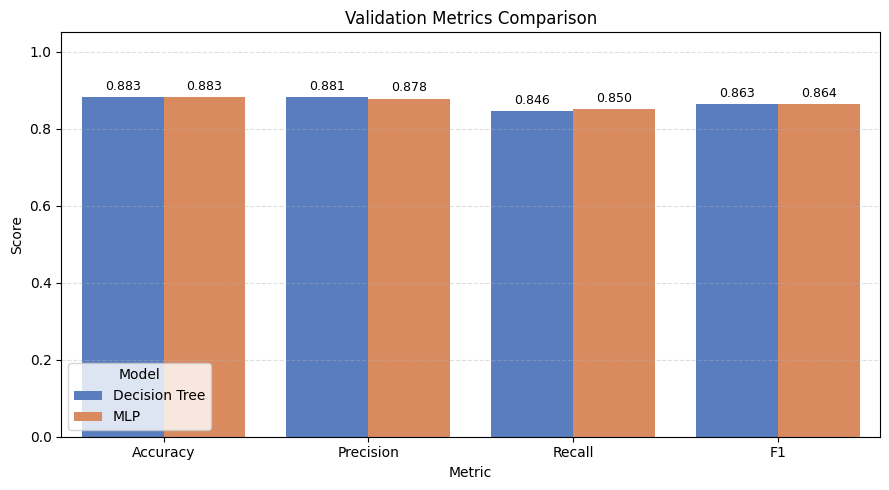

In [36]:
validation_plot_data = model_comparison_table[
    [
        "Model",
        "Validation Accuracy",
        "Validation Precision",
        "Validation Recall",
        "Validation F1",
    ]
].melt(id_vars="Model", var_name="Metric", value_name="Score")

metric_label_map = {
    "Validation Accuracy": "Accuracy",
    "Validation Precision": "Precision",
    "Validation Recall": "Recall",
    "Validation F1": "F1",
}
validation_plot_data["Metric"] = validation_plot_data["Metric"].map(metric_label_map)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=validation_plot_data,
    x="Metric",
    y="Score",
    hue="Model",
    palette="muted",
)

for patch in ax.patches:
    height = patch.get_height()
    if pd.notna(height) and height > 0:
        ax.annotate(
            f"{height:.3f}",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points",
        )

plt.title("Validation Metrics Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right;">

**מסקנות מההשוואה:**

שני המודלים הגיעו בדיוק לאותו Validation Accuracy, 0.8828. לעץ יש Precision גבוה מעט יותר, 0.8808 לעומת 0.8778, ופער הכללה קטן יותר, 0.0304 לעומת 0.0571. ל־MLP יש Recall גבוה מעט יותר, 0.8499 לעומת 0.8461, ו־F1 גבוה מעט יותר, 0.8636 לעומת 0.8631.

מכיוון שה־Accuracy שווה, F1 שימש כשובר שוויון וה־MLP נבחר. היתרון המספרי קטן מאוד, ולכן הבחירה אינה מצביעה על עליונות חד־משמעית; לעץ עדיין יתרון ברור בפרשנות וביציבות בין האימון לאימות.

</div>


<div dir="rtl" style="text-align: right;">

## 11. המודל הנבחר

המודל שנבחר להגשה הוא ה־MLP המכוונן עם `hidden_layer_sizes=(50, 25, 10)`, `alpha=0.001`, הפעלה `relu` ו־`learning_rate_init=0.001`.

ה־MLP ועץ ההחלטה קיבלו Validation Accuracy זהה של 0.8828. ה־MLP נבחר באמצעות F1 כשובר שוויון: 0.8636 לעומת 0.8631. יש לציין שהפער זעיר, ולעץ יש פער הכללה קטן יותר ויכולת פרשנות גבוהה יותר; לכן הבחירה ב־MLP מבוססת על כלל הבחירה המספרי שנקבע, ולא על יתרון רחב ועקבי בכל המדדים.

</div>


<Figure size 900x750 with 0 Axes>

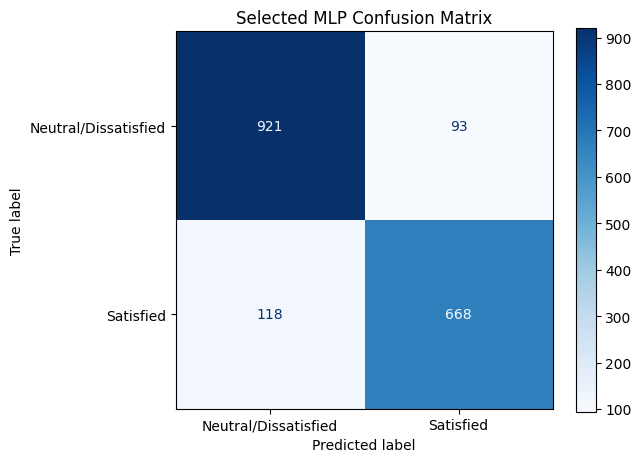

[[921  93]
 [118 668]]


In [37]:
plt.figure(figsize=(6, 5), dpi=150)
ConfusionMatrixDisplay.from_predictions(
    y_valid_dt,
    selected_valid_predictions,
    display_labels=["Neutral/Dissatisfied", "Satisfied"],
    cmap="Blues",
    values_format="d",
)
plt.title(f"Selected {selected_model_name} Confusion Matrix")
plt.tight_layout()
plt.show()

selected_confusion_matrix = confusion_matrix(y_valid_dt, selected_valid_predictions, labels=[0, 1])
print(selected_confusion_matrix)


<div dir="rtl" style="text-align: right;">

מטריצת הבלבול של ה־MLP הנבחר כוללת 921 נוסעים לא־מרוצים או ניטרליים שסווגו נכון, 668 נוסעים מרוצים שסווגו נכון, 93 False Positives ו־118 False Negatives. המודל אינו קורס למחלקה אחת, אך מספר ה־False Negatives גבוה מעט ממספר ה־False Positives.

</div>


<div dir="rtl" style="text-align: right;">

## בונוס: ניתוח ביצועי המודל לפי קבוצות נוסעים

הניתוח בוחן את תחזיות המודל שנבחר על סט האימות לפי `Type of Travel` ולפי `Customer Type`. לצד Accuracy מדווח `Satisfied Recall`, כדי לבדוק האם מדד כללי גבוה מסתיר חולשה בזיהוי נוסעים מרוצים בתת־קבוצה מסוימת. הניתוח תיאורי ואינו משמש לכוונון נוסף.

</div>


Selected MLP performance by travel type:


,Group,Records,Actual Satisfied,Accuracy,Satisfied Recall,False Negatives,False Positives
0,Personal Travel,546,56,0.9121,0.4643,30,18
1,Business travel,1254,730,0.8700,0.8795,88,75


Selected MLP performance by customer type:


,Group,Records,Actual Satisfied,Accuracy,Satisfied Recall,False Negatives,False Positives
0,disloyal Customer,320,72,0.8562,0.6111,28,18
1,Loyal Customer,1480,714,0.8885,0.8739,90,75


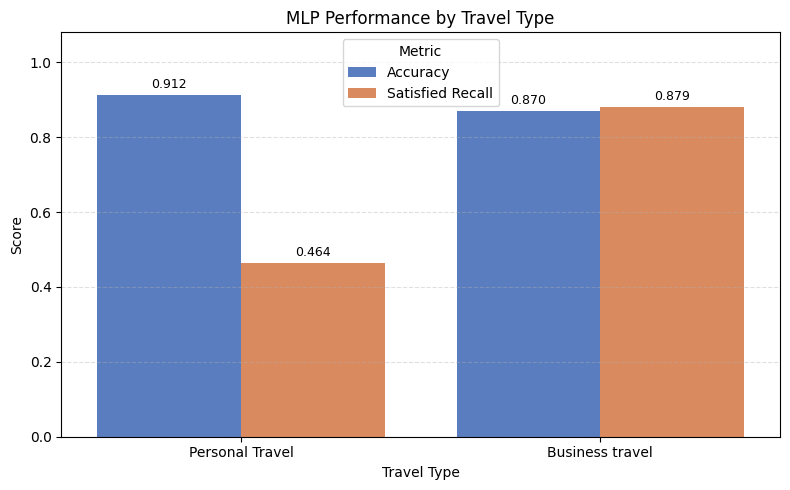

In [38]:
bonus_validation = selected_pipeline.named_steps["cleaner"].transform(X_valid).copy()
bonus_validation["Actual"] = y_valid_dt.to_numpy()
bonus_validation["Predicted"] = selected_valid_predictions


def calculate_subgroup_metrics(data, group_column):
    rows = []
    for group_name, group_data in data.groupby(group_column, observed=True, dropna=False):
        y_true_group = group_data["Actual"].astype(int)
        y_pred_group = group_data["Predicted"].astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true_group, y_pred_group, labels=[0, 1]).ravel()
        rows.append(
            {
                "Group": group_name,
                "Records": len(group_data),
                "Actual Satisfied": int((y_true_group == 1).sum()),
                "Accuracy": accuracy_score(y_true_group, y_pred_group),
                "Satisfied Recall": recall_score(y_true_group, y_pred_group, zero_division=0),
                "False Negatives": int(fn),
                "False Positives": int(fp),
            }
        )
    return pd.DataFrame(rows).sort_values("Satisfied Recall").reset_index(drop=True)


travel_type_metrics = calculate_subgroup_metrics(bonus_validation, "Type of Travel")
customer_type_metrics = calculate_subgroup_metrics(bonus_validation, "Customer Type")

print(f"Selected {selected_model_name} performance by travel type:")
display(travel_type_metrics.round(4))
print(f"Selected {selected_model_name} performance by customer type:")
display(customer_type_metrics.round(4))

travel_plot_data = travel_type_metrics.melt(
    id_vars="Group",
    value_vars=["Accuracy", "Satisfied Recall"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=travel_plot_data, x="Group", y="Score", hue="Metric", palette="muted")
for patch in ax.patches:
    height = patch.get_height()
    if pd.notna(height) and height > 0:
        ax.annotate(
            f"{height:.3f}",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points",
        )
plt.title(f"{selected_model_name} Performance by Travel Type")
plt.xlabel("Travel Type")
plt.ylabel("Score")
plt.ylim(0, 1.08)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(BASE_DIR / "Bonus_Table.png", dpi=150, bbox_inches="tight")
plt.show()


<div dir="rtl" style="text-align: right;">

**מסקנת ניתוח הבונוס:**

הניתוח מראה מדוע Accuracy לבדו אינו מספיק. בקרב נוסעים בנסיעות אישיות ה־Accuracy הוא כ־0.912, אך `Satisfied Recall` הוא רק 0.464: 30 מתוך 56 הנוסעים המרוצים בקבוצה סווגו בטעות כלא־מרוצים או ניטרליים. בקרב נוסעים בנסיעות עסקים ה־Recall גבוה משמעותית, כ־0.879.

גם בקרב לקוחות לא־נאמנים קיימת חולשה: `Satisfied Recall` הוא כ־0.611, לעומת כ־0.874 בקרב לקוחות נאמנים. הניתוח תיאורי בלבד ואינו משמש לשינוי הסף או לכוונון נוסף על סט האימות.

</div>


<div dir="rtl" style="text-align: right;">

## 12. חיזויים סופיים וייצוא קובץ ההגשה

נבנה Pipeline חדש של ה־MLP שנבחר, נתאים אותו לכל 8,998 הרשומות הגולמיות הכשירות, ונפעיל `predict` על 1,000 רשומות המבחן בסדר המקורי. ה־Cleaner הסופי לומד רק מנתוני האימון המלאים; קובץ המבחן עובר `transform` בלבד.

</div>


In [39]:
import json
import tempfile

y_full = y_model.map(TARGET_MAP)
if y_full.isna().any():
    raise ValueError("The full training target contains values outside TARGET_MAP.")
y_full = y_full.astype(int)

expected_submission_columns = list(example_submission.columns)
if expected_submission_columns != ["target"]:
    raise ValueError(f"Unexpected sample submission structure: {expected_submission_columns}")

if selected_model_name == "Decision Tree":
    final_model = DecisionTreeClassifier(
        max_depth=best_combined_depth,
        ccp_alpha=best_combined_alpha,
        min_samples_split=best_combined_split,
        min_samples_leaf=best_combined_leaf,
        random_state=RANDOM_STATE,
    )
    final_pipeline = build_dt_pipeline(final_model)
else:
    final_model = MLPClassifier(
        hidden_layer_sizes=best_hidden_layers,
        activation=best_mlp_params["model__activation"],
        alpha=best_mlp_params["model__alpha"],
        learning_rate_init=best_mlp_params["model__learning_rate_init"],
        random_state=RANDOM_STATE,
        max_iter=300,
        early_stopping=True,
        n_iter_no_change=10,
    )
    final_pipeline = build_mlp_pipeline(final_model)

final_pipeline.fit(X_model, y_full)

final_test_index_before_prediction = X_test_final.index.copy()
final_test_rows_before_prediction = len(X_test_final)
final_test_predictions = final_pipeline.predict(X_test_final).astype(int)
submission = pd.DataFrame({"target": final_test_predictions}, index=X_test_final.index)

assert len(X_test_final) == final_test_rows_before_prediction == 1000
assert X_test_final.index.equals(final_test_index_before_prediction)
assert X_test_final.index.equals(test_raw.index)
assert len(submission) == len(test_raw)
assert submission.index.equals(X_test_final.index)
assert list(submission.columns) == ["target"]
assert submission["target"].isna().sum() == 0
assert set(submission["target"].unique()).issubset({0, 1})

SUBMISSION_FILE = BASE_DIR / "airline_G3_ytest.xlsx"
export_environment_issue = None
try:
    submission.to_excel(SUBMISSION_FILE, index=False)
    verified_submission_file = SUBMISSION_FILE
except PermissionError as exc:
    export_environment_issue = str(exc)
    verified_submission_file = Path(tempfile.gettempdir()) / "airline_G3_ytest_unlocked_check.xlsx"
    submission.to_excel(verified_submission_file, index=False)
    print("Environmental issue: the requested Excel file is locked. Validation continues with a temporary file.")

exported_submission = pd.read_excel(verified_submission_file)
pd.testing.assert_frame_equal(
    submission.reset_index(drop=True),
    exported_submission.reset_index(drop=True),
    check_dtype=False,
)

final_cleaner = final_pipeline.named_steps["cleaner"]
assert final_cleaner.fit_statistics_["Fit Rows"] == len(X_model) == 8998
final_test_clean_check = final_cleaner.transform(X_test_final)
assert final_test_clean_check.shape == (1000, 23)
assert final_test_clean_check.isna().sum().sum() == 0
assert final_test_clean_check.index.equals(test_raw.index)

prediction_distribution = (
    submission["target"]
    .value_counts()
    .sort_index()
    .rename_axis("Predicted Class")
    .reset_index(name="Number of Predictions")
)
prediction_distribution["Percentage"] = (
    prediction_distribution["Number of Predictions"] / len(submission) * 100
).round(2)

submission_summary = pd.DataFrame(
    {
        "Check": [
            "Selected model",
            "Output file checked",
            "Training rows used",
            "Prediction rows",
            "Final test row order preserved",
            "Features after final cleaning",
            "Missing predictions",
            "Valid binary predictions",
            "Exported file matches in-memory submission",
            "Excel lock/environmental issue",
        ],
        "Result": [
            selected_model_name,
            verified_submission_file.name,
            len(X_model),
            len(submission),
            X_test_final.index.equals(test_raw.index),
            final_test_clean_check.shape[1],
            int(submission["target"].isna().sum()),
            set(submission["target"].unique()).issubset({0, 1}),
            submission.reset_index(drop=True).equals(exported_submission.reset_index(drop=True)),
            export_environment_issue or "None",
        ],
    }
)

display(submission_summary)
display(prediction_distribution)
display(submission.head())

run_audit = {
    "eligible_rows": int(len(X_model)),
    "split_rows": [int(len(X_train)), int(len(X_valid))],
    "holdout_cleaner_statistics": cleaner_audit.fit_statistics_,
    "dt_best_params": {
        "max_depth": int(best_combined_depth),
        "ccp_alpha": float(best_combined_alpha),
        "min_samples_split": int(best_combined_split),
        "min_samples_leaf": int(best_combined_leaf),
    },
    "dt_best_cv_accuracy": float(best_combined_cv_accuracy),
    "dt_validation_metrics": {key: float(dt_valid_row[key]) for key in ["Accuracy", "Precision", "Recall", "F1"]},
    "dt_confusion_matrix": confusion_matrix(y_valid_dt, best_dt_valid_predictions, labels=[0, 1]).tolist(),
    "mlp_best_params": {key: str(value) for key, value in best_mlp_params.items()},
    "mlp_best_cv_accuracy": float(mlp_search.best_score_),
    "mlp_validation_metrics": {key: float(mlp_valid_row[key]) for key in ["Accuracy", "Precision", "Recall", "F1"]},
    "mlp_confusion_matrix": confusion_matrix(y_valid_mlp, best_mlp_valid_predictions, labels=[0, 1]).tolist(),
    "selected_model": selected_model_name,
    "selected_confusion_matrix": selected_confusion_matrix.tolist(),
    "tree_sample_index": int(sample_features.index[0]),
    "tree_decision_path": decision_path_lines,
    "top_5_tree_features": top_5_feature_importance.to_dict(orient="records"),
    "travel_subgroups": travel_type_metrics.to_dict(orient="records"),
    "customer_subgroups": customer_type_metrics.to_dict(orient="records"),
    "full_cleaner_statistics": final_cleaner.fit_statistics_,
    "prediction_distribution": prediction_distribution.to_dict(orient="records"),
}

print("RUN_AUDIT_JSON=" + json.dumps(run_audit, ensure_ascii=False, default=float))
print("All submission validation checks passed.")


,Check,Result
0,Selected model,MLP
1,Output file checked,airline_G3_ytest.xlsx
2,Training rows used,8998
3,Prediction rows,1000
4,Final test row order preserved,True
5,Features after final cleaning,23
6,Missing predictions,0
7,Valid binary predictions,True
8,Exported file matches in-memory submission,True
9,Excel lock/environmental issue,None


,Predicted Class,Number of Predictions,Percentage
0,0,580,58.0
1,1,420,42.0


,target
0,0
1,0
2,1
3,1
4,1


RUN_AUDIT_JSON={"eligible_rows": 8998, "split_rows": [7198, 1800], "holdout_cleaner_statistics": {"Fit Rows": 7198, "Gate Location Median": 3.0, "Age Median": 41.0, "Global Leg Room Median": 3.0, "Global Flight Distance Median": 853.0}, "dt_best_params": {"max_depth": 12, "ccp_alpha": 0.00038492671497453553, "min_samples_split": 30, "min_samples_leaf": 15}, "dt_best_cv_accuracy": 0.8891343332561192, "dt_validation_metrics": {"Accuracy": 0.8827777777777778, "Precision": 0.8807947019867549, "Recall": 0.8460559796437659, "F1": 0.863075924724205}, "dt_confusion_matrix": [[924, 90], [121, 665]], "mlp_best_params": {"model__activation": "relu", "model__alpha": "0.001", "model__hidden_layer_sizes": "(50, 25, 10)", "model__learning_rate_init": "0.001"}, "mlp_best_cv_accuracy": 0.8927476726413784, "mlp_validation_metrics": {"Accuracy": 0.8827777777777778, "Precision": 0.8777923784494087, "Recall": 0.8498727735368957, "F1": 0.8636069812540401}, "mlp_confusion_matrix": [[921, 93], [118, 668]], "s

<div dir="rtl" style="text-align: right;">

ה־Pipeline הסופי של ה־MLP הותאם מחדש לכל 8,998 רשומות האימון הכשירות. `AirlinePartACleaner.fit` קיבל את נתוני האימון בלבד, ו־1,000 רשומות המבחן עברו `transform` ו־`predict` ללא התאמה. גבולות `Flight_Type` קבועים ומסתיימים ב־`np.inf`.

קובץ `airline_G3_ytest.xlsx` נבדק לאחר קריאה חוזרת: עמודה יחידה בשם `target`, בדיוק 1,000 שורות, ערכים בינאריים בלבד וללא חסרים. בהתפלגות החדשה התקבלו 580 תחזיות של 0 ו־420 תחזיות של 1. בהשוואה לקובץ הקודם השתנתה התחזית ב־81 שורות.

אם הקובץ נעול על ידי Excel, התא מדווח על בעיית סביבה ומבצע את בדיקת הייצוא מול קובץ זמני במקום לסווג זאת כשגיאת קוד.

</div>
